**LIBRARY**

In [ ]:
import os
import shutil
import cvxpy as cp
from google.colab import files

!pip install -q scs cvxpy cvxopt

try:
    solvers = cp.installed_solvers()
    print("Các solver khả dụng:", solvers)
except Exception as e:
    print(f"Lỗi kiểm tra solvers: {e}")

Các solver khả dụng: ['CLARABEL', 'CVXOPT', 'GLPK', 'GLPK_MI', 'HIGHS', 'MOSEK', 'OSQP', 'SCIPY', 'SCS']


**DATA**

In [ ]:
import numpy as np
from sklearn.datasets import load_svmlight_file
import requests, os, bz2, urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

def download_libsvm_data(url, filename, timeout=30):
    if os.path.exists(filename):
        return load_svmlight_file(filename)
    is_bz2 = url.endswith(".bz2")
    temp_filename = filename + ".bz2" if is_bz2 else filename
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        r = requests.get(url, headers=headers, allow_redirects=True, timeout=timeout, verify=False)
        r.raise_for_status()
        with open(temp_filename, "wb") as f: f.write(r.content)
        if is_bz2:
            with bz2.open(temp_filename, "rb") as f_in, open(filename, "wb") as f_out:
                while chunk := f_in.read(1024 * 1024): f_out.write(chunk)
            os.remove(temp_filename)
        return load_svmlight_file(filename)
    except requests.exceptions.Timeout:
        print(f"[ERROR] Request timed out for {url}"); raise
    except requests.exceptions.RequestException as e:
        print(f"[ERROR] Request failed for {url}: {e}"); raise
    except bz2.BZ2Error as e:
        print(f"[ERROR] Failed to decompress {url}: {e}"); raise

libsvm_datasets_info = {"svmguide1": {"train": "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/svmguide1"}, "ijcnn1": {"train": "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/ijcnn1.bz2"}, "phishing": {"train": "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/phishing"}}
loaded_datasets_raw = {}

for name, urls in libsvm_datasets_info.items():
    try:
        X_tr, y_tr = download_libsvm_data(urls["train"], f"{name}_train.svm")
        y_tr = np.where(y_tr > 0, 1, -1).astype(np.float64)
        X_te_dummy = np.empty((0, X_tr.shape[1]))
        y_te_dummy = np.empty(0)
        loaded_datasets_raw[name] = (X_tr, y_tr, X_te_dummy, y_te_dummy)
        print(f"[OK] Loaded {name}: {X_tr.shape[0]:,} samples, {X_tr.shape[1]:,} features")
    except Exception as e:
        print(f"[ERROR] Failed to load {name}: {e}")

print("\n" + "=" * 75)
print("DATASET SUMMARY")
print("=" * 75)
print(f"{'Dataset':<15}{'Train (Full)':>15}{'Features':>12}{'Class -1':>15}{'Class +1':>15}")
print("-" * 75)

for name, (X_tr, y_tr, _, _) in loaded_datasets_raw.items():
    n_train = X_tr.shape[0]
    n_features = X_tr.shape[1]
    n_class_neg = np.sum(y_tr == -1)
    n_class_pos = np.sum(y_tr == 1)
    print(f"{name:<15}{n_train:>15,}{n_features:>12,}{n_class_neg:>15,}{n_class_pos:>15,}")

print("-" * 75)
print(f"\nAll datasets loaded: {list(loaded_datasets_raw.keys())}")

[OK] Loaded svmguide1: 3,089 samples, 4 features
[OK] Loaded ijcnn1: 49,990 samples, 22 features
[OK] Loaded phishing: 11,055 samples, 68 features

DATASET SUMMARY
Dataset           Train (Full)    Features       Class -1       Class +1
---------------------------------------------------------------------------
svmguide1                3,089           4          1,089          2,000
ijcnn1                  49,990          22         45,137          4,853
phishing                11,055          68          4,898          6,157
---------------------------------------------------------------------------

All datasets loaded: ['svmguide1', 'ijcnn1', 'phishing']


**GET SPLIT**

In [ ]:
from sklearn.preprocessing import StandardScaler

def prepare_fixed_split(X_full, y_full):

    scaler = StandardScaler(with_mean=False)
    X_full_scaled = scaler.fit_transform(X_full)

    if hasattr(X_full_scaled, "toarray"):
        X_full_scaled = X_full_scaled.toarray()

    return X_full_scaled, y_full


fixed_splits = {}
for _name, (_Xfull, _yfull, _, _) in loaded_datasets_raw.items():
    fixed_splits[_name] = prepare_fixed_split(_Xfull, _yfull)

**THRESHOLD**

In [ ]:
def tune_threshold(y_val, decision_scores_val, n_steps=200):

    lo = decision_scores_val.min()
    hi = decision_scores_val.max()

    if lo == hi:
        return 0.0

    thresholds = np.linspace(lo, hi, n_steps)

    best_thr = 0.0
    best_f1 = -1.0

    for thr in thresholds:

        pred = np.where(
            decision_scores_val >= thr,
            1,
            -1
        )

        f1_val = f1_score(
            y_val,
            pred,
            zero_division=0
        )

        if f1_val > best_f1:
            best_f1 = f1_val
            best_thr = thr

    return best_thr

**ROBUST SVM**

In [ ]:
import time
import cvxpy as cp
import numpy as np


_PROBLEM_CACHE = {}

def _get_or_build_problem(n, d):
    key = (n, d)
    if key in _PROBLEM_CACHE:
        return _PROBLEM_CACHE[key]

    w = cp.Variable(d)
    t = cp.Variable(nonneg=True)
    xi = cp.Variable(n, nonneg=True)

    X_p = cp.Parameter((n, d))
    y_p = cp.Parameter(n)
    rho_p = cp.Parameter(n, nonneg=True)
    C_p = cp.Parameter(nonneg=True)

    constraints = [
        1 - cp.multiply(y_p, X_p @ w) + cp.multiply(rho_p, t) <= xi,
        cp.SOC(t, w)
    ]
    objective = cp.Minimize(0.5 * cp.square(t) + C_p * cp.sum(xi))
    prob = cp.Problem(objective, constraints)

    entry = dict(prob=prob, w=w, t=t, xi=xi,
                 X_p=X_p, y_p=y_p, rho_p=rho_p, C_p=C_p,
                 constraints=constraints)
    _PROBLEM_CACHE[key] = entry
    return entry

def train_robust_svm(
        X_train,
        y_train,
        C,
        rho,
        max_iters=4000,
        eps=1e-6,
        w_init=None,
        use_warm_start=True,
        verbose=False,
        solver_name='SCS'):

    n, d = X_train.shape
    entry = _get_or_build_problem(n, d)
    prob, w, t, xi = entry['prob'], entry['w'], entry['t'], entry['xi']

    entry['X_p'].value = X_train
    entry['y_p'].value = y_train
    entry['rho_p'].value = rho
    entry['C_p'].value = C

    solver_map = {'SCS': cp.SCS, 'CVXOPT': cp.CVXOPT}
    chosen_solver = solver_map.get(solver_name, cp.SCS)

    solver_opts = {
        'verbose': verbose,
        'warm_start': bool(use_warm_start),
    }

    if chosen_solver == cp.SCS:
        solver_opts['max_iters'] = max_iters
        solver_opts['eps'] = eps
    elif chosen_solver == cp.CVXOPT:
        solver_opts['maxiters'] = max_iters
        solver_opts['abstol'] = eps
        solver_opts['reltol'] = eps
        solver_opts['feastol'] = eps

    start = time.time()
    try:
        prob.solve(solver=chosen_solver, **solver_opts)
    except Exception as e:
        print(f"Solver {solver_name} error: {e}")
        return None, None, 0.0, None
    end = time.time()

    num_iters = (
        getattr(prob.solver_stats, 'num_iters', None)
        if prob.solver_stats is not None else None
    )

    if prob.status not in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
        return None, None, end - start, num_iters

    w_val = w.value.copy() if w.value is not None else None
    alpha = entry['constraints'][0].dual_value
    if alpha is not None:
        alpha = np.clip(alpha, 0, C).copy()

    return w_val, alpha, end - start, num_iters

**SAFE SCREENIG FOR ROBUST SVM**

In [ ]:
def screen(y, rho, R_val, indices, normX_all, Xw_at_indices, w_norm):

    idx_array = np.asarray(indices)

    y_sub = y[idx_array]
    rho_sub = rho[idx_array]
    normX_sub = normX_all[idx_array]

    margins = y_sub * Xw_at_indices
    w_norm_minus_R = max(w_norm - R_val, 0.0)

    LB = margins - rho_sub * (w_norm + R_val) - R_val * normX_sub
    UB = margins - rho_sub * w_norm_minus_R + R_val * normX_sub

    mask_N = LB > 1.0
    mask_S = UB < 1.0

    N_k = set(idx_array[mask_N])
    S_k = set(idx_array[mask_S])
    F_k_new = set(idx_array[~(mask_N | mask_S)])

    return N_k, S_k, F_k_new

def dynamic_safe_screening(X, y, rho, C,
                           tol_gap=1e-6, min_F_size=0,
                           initial_reltol=1e-2, final_reltol=1e-3,
                           max_reductions=2,
                           max_iters=1000,
                           verbose=False,
                           solver_name='SCS',
                           try_fix_bounded=True):
    n, d = X.shape
    normX_all = np.linalg.norm(X, axis=1)

    total_start = time.time()
    all_idx = np.arange(n)
    w_prev = np.zeros(d)

    solve_history = []
    F = set(all_idx)
    R, S = set(), set()
    iteration, reductions, stall_count = 1, 1, 0

    R_val = 0.0
    gap = float('inf')
    total_solve_time = 0.0
    total_solver_iters = 0

    reltol = None

    while len(F) > min_F_size and reductions <= max_reductions:
        F_list = np.fromiter(F, dtype=int)
        S_list = np.fromiter(S, dtype=int) if len(S) > 0 else np.array([], dtype=int)
        A_list = np.concatenate([F_list, S_list]) if S_list.size > 0 else F_list

        reltol = max(initial_reltol * (0.2 ** reductions), final_reltol)
        A_list_solved = np.sort(A_list)

        w_new, alpha_A, solve_time_iter, iters_iter = train_robust_svm(
            X_train=X[A_list], y_train=y[A_list], C=C, rho=rho[A_list],
            use_warm_start=True, max_iters=max_iters, eps=reltol,
            solver_name=solver_name
        )
        total_solve_time += solve_time_iter
        total_solver_iters += (iters_iter or 0)

        if w_new is None:
            print(f"train_robust_svm failed at iteration {iteration}. Exiting screening.")
            return {
                'A': F.union(S), 'F': F, 'S': S, 'R': R, 'R_val': R_val, 'gap': gap,
                'reduction_rate': len(R) / n, 'active_rate': len(F.union(S)) / n,
                'time': time.time() - total_start, 'solve_time': total_solve_time,
                'solver_iters': total_solver_iters,
                'reltol': reltol,
                'history': solve_history,
                'w': w_prev, 'alpha': None
            }

        w_prev = w_new
        X_A = X[A_list]; y_A = y[A_list]; rho_A = rho[A_list]
        Xw_A = X_A @ w_new
        n_F = len(F_list)
        Xw_F = Xw_A[:n_F]
        t_new = np.linalg.norm(w_new)

        Xw_full = X @ w_new
        xi_full = np.maximum(0, 1 - y * Xw_full + rho * t_new)
        primal = 0.5 * t_new**2 + C * np.sum(xi_full)

        norm_d = np.linalg.norm(X_A.T @ (alpha_A * y_A)) if alpha_A is not None else 0
        s = np.sum(alpha_A * rho_A) if alpha_A is not None else 0
        dual = np.sum(alpha_A) - 0.5 * max(norm_d - s, 0.0)**2 if alpha_A is not None else 0

        gap = max(primal - dual, 1e-6) if iteration == 1 else max(primal - dual, 1e-12)
        R_val = max(np.sqrt(2.0 * gap), 1e-12)

        R_k, S_k, F_new = screen(
            y, rho, R_val, F_list, normX_all, Xw_at_indices=Xw_F, w_norm=t_new
        )

        removed = len(F) - len(F_new)
        yield_ratio = removed / max(n_F, 1)

        if removed == 0:
            stall_count += 1
        else:
            stall_count = 0

        R.update(R_k); S.update(S_k); F = set(F_new)

        if verbose:
            print(f"[iter {iteration}] |R|={len(R)} |S|={len(S)} |F|={len(F)} yield={yield_ratio:.2f}")

        if stall_count >= 2 or gap < tol_gap:
            break

        reductions += 1
        iteration += 1

    total_time = time.time() - total_start
    A = F.union(S)
    return {
        'A': A, 'F': F, 'S': S, 'R': R, 'R_val': R_val, 'gap': gap,
        'reduction_rate': len(R) / n,
        'active_rate': len(A) / n,
        'time': total_time, 'solve_time': total_solve_time,
        'solver_iters': total_solver_iters,
        'reltol': reltol,
        'history': solve_history,
        'w': w_prev, 'alpha': alpha_A,
        'A_solved': A_list_solved
    }

**RESULTS**

In [ ]:
DATASETS_TO_RUN = ['svmguide1', 'phishing', 'ijcnn1']
SOLVERS = ['SCS', 'CVXOPT']
C_VALS = [0.01, 0.05, 0.1]
RHO_VALS = [0.0, 0.05]
METHODS = ['Baseline', 'Screening']
WARM_START_SETTINGS = [False, True]
N_SEEDS = 30
SEEDS = list(range(1, N_SEEDS + 1))

print("Experiment setup:")
print(f"Datasets       : {DATASETS_TO_RUN}")
print(f"Solvers        : {SOLVERS}")
print(f"C values       : {C_VALS}")
print(f"rho values     : {RHO_VALS}")
print(f"Methods        : {METHODS}")
print(f"Warm start     : {WARM_START_SETTINGS}")
print(f"Seeds          : {SEEDS}")

Experiment setup:
Datasets       : ['svmguide1', 'phishing', 'ijcnn1']
Solvers        : ['SCS', 'CVXOPT']
C values       : [0.01, 0.05, 0.1]
rho values     : [0.0, 0.05]
Methods        : ['Baseline', 'Screening']
Warm start     : [False, True]
Seeds          : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


**SETUP SAVE FILE**

In [ ]:
import os
import csv
import time
import io
import pandas as pd
from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload, MediaIoBaseDownload

# 1. XÁC THỰC & KHỞI TẠO DRIVE API (KHÔNG dùng FUSE mount nữa)
auth.authenticate_user()
drive_service = build('drive', 'v3')
DRIVE_FOLDER_NAME = 'RSVM_Experiments_final'
DRIVE_FILENAME    = 'master_results.csv'


# 2. THƯ MỤC LOCAL - chỉ để đọc nhanh, KHÔNG phải nơi an toàn
LOCAL_DIR = '/content/RSVM_Experiments_final'
os.makedirs(LOCAL_DIR, exist_ok=True)
LOCAL_BENCHMARK_FILE = os.path.join(LOCAL_DIR, 'master_results.csv')
BENCHMARK_FILE = LOCAL_BENCHMARK_FILE
RESULT_COLUMNS = [
    'Dataset', 'Solver', 'WarmStart', 'C', 'Rho', 'Method', 'Seed',
    'Objective', 'Accuracy', 'AUC', 'F1',
    'ScreeningRate', 'Time', 'ScreenTime', 'Iterations', 'Status'
]

# 3. TÌM / TẠO FOLDER + FILE TRÊN DRIVE (qua API, không qua path)
def _get_or_create_folder():
    query = (
        f"name='{DRIVE_FOLDER_NAME}' and "
        f"mimeType='application/vnd.google-apps.folder' and trashed=false"
    )
    res = drive_service.files().list(q=query, fields='files(id,name)').execute()
    files = res.get('files', [])
    if files:
        return files[0]['id']
    meta = {'name': DRIVE_FOLDER_NAME, 'mimeType': 'application/vnd.google-apps.folder'}
    folder = drive_service.files().create(body=meta, fields='id').execute()
    return folder['id']

def _find_drive_file_id():
    query = f"name='{DRIVE_FILENAME}' and '{FOLDER_ID}' in parents and trashed=false"
    res = drive_service.files().list(
        q=query, fields='files(id,name,modifiedTime)',
        orderBy='modifiedTime desc'
    ).execute()
    files = res.get('files', [])
    return files[0]['id'] if files else None

FOLDER_ID = _get_or_create_folder()
DRIVE_FILE_ID = _find_drive_file_id()
# 4. TẢI CHECKPOINT MỚI NHẤT (ĐÃ ĐƯỢC GOOGLE XÁC NHẬN) VỀ LOCAL
def download_drive_checkpoint():
    global DRIVE_FILE_ID
    DRIVE_FILE_ID = _find_drive_file_id()
    if DRIVE_FILE_ID is None:
        print('[INIT] Chưa có file nào trên Drive — sẽ tạo mới khi có kết quả đầu tiên.')
        return False

    request = drive_service.files().get_media(fileId=DRIVE_FILE_ID)
    fh = io.FileIO(LOCAL_BENCHMARK_FILE, 'wb')
    downloader = MediaIoBaseDownload(fh, request)
    done = False
    while not done:
        _, done = downloader.next_chunk()
    fh.close()
    print(f'[INIT] Đã tải checkpoint xác nhận từ Drive về local: {LOCAL_BENCHMARK_FILE}')
    return True

# 5. GHI CHECKPOINT LÊN DRIVE (BLOCKING - chờ Google xác nhận)
def checkpoint_to_drive():
    global DRIVE_FILE_ID
    media = MediaFileUpload(LOCAL_BENCHMARK_FILE, mimetype='text/csv', resumable=True)

    if DRIVE_FILE_ID is None:
        meta = {'name': DRIVE_FILENAME, 'parents': [FOLDER_ID]}
        f = drive_service.files().create(body=meta, media_body=media, fields='id').execute()
        DRIVE_FILE_ID = f['id']
    else:
        drive_service.files().update(fileId=DRIVE_FILE_ID, media_body=media).execute()

    print(f'[CHECKPOINT] Drive đã xác nhận lưu lúc {time.strftime("%H:%M:%S")}')

# 6. LOAD KẾT QUẢ HIỆN CÓ + BUILD COMPLETED KEY
def load_existing_results():
    if (
        not os.path.exists(LOCAL_BENCHMARK_FILE)
        or os.path.getsize(LOCAL_BENCHMARK_FILE) == 0
    ):
        with open(
            LOCAL_BENCHMARK_FILE,
            'w',
            newline='',
            encoding='utf-8'
        ) as f:
            csv.writer(f).writerow(RESULT_COLUMNS)

        return pd.DataFrame(columns=RESULT_COLUMNS)
    with open(
        LOCAL_BENCHMARK_FILE,
        'r',
        encoding='utf-8-sig'
    ) as f:
        first_line = f.readline().strip()
    first_columns = [
        x.strip() for x in first_line.split(',')
    ]
    has_header = (
        first_columns == RESULT_COLUMNS
        or 'Dataset' in first_columns
    )
    if has_header:
        df = pd.read_csv(
            LOCAL_BENCHMARK_FILE
        )
    else:
        print(
            '[WARNING] Local CSV không có header. '
            'Đang khôi phục header, không bỏ dòng đầu tiên.'
        )

        df = pd.read_csv(
            LOCAL_BENCHMARK_FILE,
            header=None,
            names=RESULT_COLUMNS
        )

        df.to_csv(
            LOCAL_BENCHMARK_FILE,
            index=False
        )

    for col in RESULT_COLUMNS:
        if col not in df.columns:
            df[col] = None

    df = df[RESULT_COLUMNS]

    print(f'[INIT] Số kết quả đã có: {len(df)} dòng')

    return df

def make_experiment_key(dataset, solver, warm_start, C, rho, method, seed):
    return (str(dataset), str(solver), bool(warm_start), float(C),
            float(rho), str(method), int(seed))

def _row_key_safe(row):
    try:
        return make_experiment_key(
            row['Dataset'], row['Solver'], row['WarmStart'],
            row['C'], row['Rho'], row['Method'], row['Seed']
        )
    except Exception:
        return None

def _is_success_row(row):
    status_ok = str(row.get('Status', '')).upper() == 'SUCCESS'
    obj_val = row.get('Objective', None)
    obj_ok = obj_val is not None and str(obj_val).strip() != '' and not pd.isna(obj_val)
    return status_ok and obj_ok

def build_completed_keys(df):
    completed = set()
    if df.empty:
        return completed
    for _, row in df.iterrows():
        if not _is_success_row(row):
            continue
        key = _row_key_safe(row)
        if key is not None:
            completed.add(key)
    return completed

def dedupe_results(df):
    if df.empty:
        return df, 0

    ordered_keys = []
    best_row_for_key = {}
    unkeyable_rows = []

    for _, row in df.iterrows():
        key = _row_key_safe(row)
        if key is None:
            unkeyable_rows.append(row.to_dict())
            continue

        is_success = _is_success_row(row)
        if key not in best_row_for_key:
            ordered_keys.append(key)
            best_row_for_key[key] = (is_success, row.to_dict())
        else:
            prev_success, _ = best_row_for_key[key]
            if is_success or not prev_success:
                best_row_for_key[key] = (is_success, row.to_dict())

    cleaned_rows = [best_row_for_key[k][1] for k in ordered_keys] + unkeyable_rows
    cleaned_df = pd.DataFrame(cleaned_rows, columns=RESULT_COLUMNS)
    return cleaned_df, len(df) - len(cleaned_df)

# 7. GHI LOCAL (mỗi dòng - chỉ để đọc, không phải nơi an toàn)
_results_store = {}
_results_key_order = []

def _init_results_store_from_df(df):
    global _results_store, _results_key_order
    _results_store = {}
    _results_key_order = []
    for _, row in df.iterrows():
        row_dict = row.to_dict()
        key = _row_key_safe(row_dict) or ('__unkeyable__', len(_results_key_order))
        _results_key_order.append(key)
        _results_store[key] = row_dict

def _rewrite_local_file():
    with open(LOCAL_BENCHMARK_FILE, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=RESULT_COLUMNS)
        writer.writeheader()
        for key in _results_key_order:
            writer.writerow(_results_store[key])
        f.flush()
        os.fsync(f.fileno())

def save_local_result(row):
    key = _row_key_safe(row) or ('__unkeyable__', len(_results_key_order))
    if key in _results_store:
        prev_ok = _is_success_row(_results_store[key])
        new_ok = _is_success_row(row)
        if prev_ok and not new_ok:
            print(f'        [GUARD] Bỏ qua: key đã SUCCESS, không cho {row.get("Status")} đè lên.')
            return
        _results_store[key] = row
    else:
        _results_key_order.append(key)
        _results_store[key] = row
    _rewrite_local_file()

# 8. SAVE_RESULT: local mỗi dòng + checkpoint Drive theo chu kỳ
CHECKPOINT_EVERY_N   = 1
CHECKPOINT_EVERY_SEC = 10

_rows_since_checkpoint = 0
_last_checkpoint_time = time.time()

def save_result(row):
    global _rows_since_checkpoint, _last_checkpoint_time

    save_local_result(row)
    _rows_since_checkpoint += 1

    need_checkpoint = (
        _rows_since_checkpoint >= CHECKPOINT_EVERY_N
        or (time.time() - _last_checkpoint_time) >= CHECKPOINT_EVERY_SEC
    )

    if need_checkpoint:
        try:
            checkpoint_to_drive()
            _rows_since_checkpoint = 0
            _last_checkpoint_time = time.time()
        except Exception as e:
            print(f'[WARNING] Checkpoint Drive thất bại, sẽ thử lại ở checkpoint kế tiếp: {e}')

def force_checkpoint_now():
    """Gọi hàm này trong finally/except để chốt dữ liệu khi dừng tay hoặc gặp lỗi."""
    try:
        checkpoint_to_drive()
        global _rows_since_checkpoint, _last_checkpoint_time
        _rows_since_checkpoint = 0
        _last_checkpoint_time = time.time()
    except Exception as e:
        print(f'[WARNING] Force checkpoint thất bại: {e}')

# 9. KHỞI ĐỘNG
download_drive_checkpoint()
existing_results = load_existing_results()

existing_results, n_dupes_removed = dedupe_results(existing_results)
if n_dupes_removed > 0:
    print(f'[CLEANUP] Đã gộp/loại bỏ {n_dupes_removed} dòng trùng lặp trong master_results.csv.')
    with open(LOCAL_BENCHMARK_FILE, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=RESULT_COLUMNS)
        writer.writeheader()
        for _, r in existing_results.iterrows():
            writer.writerow(r.to_dict())
    try:
        checkpoint_to_drive()
        print('[CLEANUP] Đã đồng bộ bản đã dọn dẹp lên Drive.')
    except Exception as e:
        print(f'[WARNING] Không thể checkpoint bản đã dọn dẹp lên Drive: {e}')

_init_results_store_from_df(existing_results)
completed_keys = build_completed_keys(existing_results)
expected_keys = set()
for dataset in DATASETS_TO_RUN:
    for solver in SOLVERS:
        for warm_start in WARM_START_SETTINGS:
            for seed in SEEDS:
                for C in C_VALS:
                    for rho in RHO_VALS:
                        for method in METHODS:

                            key = make_experiment_key(
                                dataset,
                                solver,
                                warm_start,
                                C,
                                rho,
                                method,
                                seed
                            )

                            expected_keys.add(key)

missing_keys = expected_keys - completed_keys

print()
print('==============================================')
print('             RESUME CHECK')
print('==============================================')
print(f'Expected experiments : {len(expected_keys)}')
print(f'Completed SUCCESS    : {len(completed_keys)}')
print(f'Missing experiments  : {len(missing_keys)}')

if missing_keys:
    print('[RESUME] Có experiment chưa SUCCESS.')
else:
    print('[RESUME] Tất cả experiment đã SUCCESS.')

[INIT] Đã tải checkpoint xác nhận từ Drive về local: /content/RSVM_Experiments_final/master_results.csv
[INIT] Số kết quả đã có: 4320 dòng

             RESUME CHECK
Expected experiments : 4320
Completed SUCCESS    : 4320
Missing experiments  : 0
[RESUME] Tất cả experiment đã SUCCESS.


In [ ]:
import csv
import time
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
import os
from sklearn.preprocessing import StandardScaler

def run_main_benchmark():

    global fixed_splits
    global completed_keys

    total_start_time = time.time()

    # Tổng số experiment
    total_experiments = (
        len(DATASETS_TO_RUN)
        * len(SOLVERS)
        * len(WARM_START_SETTINGS)
        * len(SEEDS)
        * len(C_VALS)
        * len(RHO_VALS)
        * len(METHODS)
    )

    print()
    print('==============================================')
    print('        R-SVM BENCHMARK WITH RESUME')
    print('==============================================')
    print(f'Total experiments : {total_experiments}')
    print(f'Already completed : {len(completed_keys)}')
    print(f'Remaining         : {total_experiments - len(completed_keys)}')
    print(f'Result file       : {BENCHMARK_FILE}')
    print('==============================================')
    print()

    for dataset_name in DATASETS_TO_RUN:

        if dataset_name not in fixed_splits:

            print(f'Skipping {dataset_name}: data not loaded.')

            continue

        X_full_dataset, y_full_dataset = fixed_splits[dataset_name]

        print(
            f'\n>>> Processing Dataset: {dataset_name} '
            f'(full_dataset={X_full_dataset.shape}) <<<'
        )

        for solver_name in SOLVERS:

            print(f'\n  Running Solver: {solver_name}')

            for warm_start_status in WARM_START_SETTINGS:

                print(
                    f'\n    WarmStart = {warm_start_status}'
                )

                for seed in SEEDS:

                    print(f'\n      Seed: {seed}')

                    X_trainval_subset, X_test_subset_generated, \
                    y_trainval_subset, y_test_subset_generated = train_test_split(

                        X_full_dataset,
                        y_full_dataset,
                        test_size=0.2,
                        random_state=seed,
                        stratify=y_full_dataset
                    )

                    X_train_subset, X_val_subset, \
                    y_train_subset, y_val_subset = train_test_split(

                        X_trainval_subset,
                        y_trainval_subset,
                        test_size=0.2,
                        random_state=seed,
                        stratify=y_trainval_subset
                    )

                    n_train_subset = len(y_train_subset)

                    for C_val in C_VALS:

                        for rho_val in RHO_VALS:

                            rho_vec = np.ones(
                                n_train_subset
                            ) * rho_val

                            for method in METHODS:

                                experiment_key = make_experiment_key(
                                    dataset_name,
                                    solver_name,
                                    warm_start_status,
                                    C_val,
                                    rho_val,
                                    method,
                                    seed
                                )

                                if experiment_key in completed_keys:

                                    print(
                                        f'        SKIP | '
                                        f'{dataset_name} | '
                                        f'{solver_name} | '
                                        f'WarmStart={warm_start_status} | '
                                        f'C={C_val} | '
                                        f'rho={rho_val} | '
                                        f'{method} | '
                                        f'seed={seed}'
                                    )

                                    continue

                                print(
                                    f'        RUN  | '
                                    f'{dataset_name} | '
                                    f'{solver_name} | '
                                    f'WarmStart={warm_start_status} | '
                                    f'C={C_val} | '
                                    f'rho={rho_val} | '
                                    f'{method} | '
                                    f'seed={seed}'
                                )

                                obj = None
                                acc = None
                                auc = None
                                f1 = None
                                best_thr = 0.0
                                s_rate = 0.0
                                solve_time = None
                                screen_time = 0.0
                                solver_iters = None
                                solve_tol = None

                                start_wall = time.time()

                                try:

                                    if method == 'Baseline':

                                        w, alpha, solve_time, solver_iters = train_robust_svm(

                                            X_train_subset,
                                            y_train_subset,
                                            C_val,
                                            rho_vec,

                                            max_iters=20000,
                                            eps=1e-6,

                                            use_warm_start=warm_start_status,
                                            solver_name=solver_name
                                        )

                                        s_rate = 0.0
                                        solve_tol = 1e-6

                                        active_idx = np.arange(
                                            n_train_subset
                                        )

                                    else:

                                        scr = dynamic_safe_screening(

                                            X_train_subset,
                                            y_train_subset,
                                            rho_vec,
                                            C_val,

                                            max_reductions=2,
                                            verbose=False,
                                            solver_name=solver_name
                                        )

                                        solve_time = scr.get('solve_time', 0.0)
                                        screen_time = max(
                                            scr.get('time', 0.0) - solve_time, 0.0
                                        )
                                        solver_iters = scr.get('solver_iters', 0)

                                        if (
                                            scr['gap'] <= 5e-3
                                            and scr.get('w') is not None
                                        ):

                                            w = scr['w']
                                            alpha = scr.get('alpha')

                                            A_idx = scr['A_solved']

                                            solve_tol = scr.get(
                                                'reltol'
                                            )

                                        else:

                                            A_idx = sorted(
                                                list(scr['A'])
                                            )

                                            w, alpha, refit_time, refit_iters = train_robust_svm(

                                                X_train_subset[A_idx],
                                                y_train_subset[A_idx],
                                                C_val,
                                                rho_vec[A_idx],

                                                max_iters=20000,
                                                eps=1e-6,

                                                use_warm_start=warm_start_status,
                                                solver_name=solver_name
                                            )

                                            solve_time += refit_time
                                            solver_iters += (refit_iters or 0)

                                            solve_tol = 1e-6

                                        s_rate = scr['reduction_rate']

                                        active_idx = np.asarray(
                                            A_idx
                                        )

                                    if w is not None:

                                        t_val = np.linalg.norm(w)

                                        xi_val = np.maximum(
                                            0,
                                            1
                                            - y_train_subset
                                            * (X_train_subset @ w)
                                            + rho_vec * t_val
                                        )

                                        obj = (
                                            0.5 * t_val**2
                                            + C_val * np.sum(xi_val)
                                        )
                                        decision_scores_val = (
                                            X_val_subset @ w
                                        )
                                        best_thr = tune_threshold(
                                            y_val_subset,
                                            decision_scores_val
                                        )
                                        decision_scores_test = (
                                            X_test_subset_generated @ w
                                        )
                                        y_pred_test = np.where(
                                            decision_scores_test >= best_thr,
                                            1,
                                            -1
                                        )
                                        acc = accuracy_score(
                                            y_test_subset_generated,
                                            y_pred_test
                                        )
                                        try:

                                            if not np.all(
                                                np.isfinite(
                                                    decision_scores_test
                                                )
                                            ):
                                                raise ValueError(
                                                    'decision scores contain NaN/Inf'
                                                )

                                            auc = roc_auc_score(
                                                y_test_subset_generated,
                                                decision_scores_test
                                            )

                                        except ValueError as auc_err:

                                            print(
                                                f'        [Warn] AUC skip '
                                                f'({dataset_name}, '
                                                f'C={C_val}, '
                                                f'rho={rho_val}, '
                                                f'{method}): '
                                                f'{auc_err}'
                                            )

                                            auc = None


                                        try:

                                            f1 = f1_score(
                                                y_test_subset_generated,
                                                y_pred_test,
                                                zero_division=0
                                            )

                                        except ValueError as f1_err:

                                            print(
                                                f'        [Warn] F1 skip '
                                                f'({dataset_name}, '
                                                f'C={C_val}, '
                                                f'rho={rho_val}, '
                                                f'{method}): '
                                                f'{f1_err}'
                                            )

                                            f1 = None

                                    wall_time = time.time() - start_wall

                                    row = {

                                        'Dataset': dataset_name,
                                        'Solver': solver_name,
                                        'WarmStart': warm_start_status,
                                        'C': C_val,
                                        'Rho': rho_val,
                                        'Method': method,
                                        'Seed': seed,

                                        'Objective': (
                                            f'{obj:.8f}'
                                            if obj is not None
                                            else None
                                        ),

                                        'Accuracy': (
                                            f'{acc:.8f}'
                                            if acc is not None
                                            else None
                                        ),

                                        'AUC': (
                                            f'{auc:.8f}'
                                            if auc is not None
                                            else None
                                        ),

                                        'F1': (
                                            f'{f1:.8f}'
                                            if f1 is not None
                                            else None
                                        ),

                                        'ScreeningRate': (
                                            f'{s_rate:.8f}'
                                            if s_rate is not None
                                            else None
                                        ),

                                        'Time': (
                                            f'{solve_time:.8f}'
                                            if solve_time is not None
                                            else f'{wall_time:.8f}'
                                        ),

                                        'ScreenTime': (
                                            f'{screen_time:.8f}'
                                            if screen_time is not None
                                            else None
                                        ),

                                        'Iterations': (
                                            solver_iters
                                            if solver_iters is not None
                                            else None
                                        ),

                                        'Status': 'SUCCESS' if w is not None else 'NO_SOLUTION'
                                    }

                                    save_result(row)

                                    if row['Status'] == 'SUCCESS':
                                        completed_keys.add(
                                            experiment_key
                                        )

                                    print(
                                        f'        SAVED ✓ | '
                                        f'Time={wall_time:.2f}s | '
                                        f'Drive={BENCHMARK_FILE}'
                                    )

                                    print(
                                        f'        SAVED ✓ | '
                                        f'Time={wall_time:.2f}s | '
                                        f'Drive={BENCHMARK_FILE}'
                                    )

                                except Exception as e:

                                    wall_time = time.time() - start_wall

                                    print(
                                        f'        ERROR ✗ | '
                                        f'{dataset_name} | '
                                        f'{solver_name} | '
                                        f'WarmStart={warm_start_status} | '
                                        f'C={C_val} | '
                                        f'rho={rho_val} | '
                                        f'{method} | '
                                        f'seed={seed}'
                                    )

                                    print(
                                        f'        Error: {e}'
                                    )

                                    if experiment_key in completed_keys:

                                        print(
                                            '        [INFO] Experiment already '
                                            'marked SUCCESS. FAILED record skipped.'
                                        )

                                        continue

                                    error_row = {

                                        'Dataset': dataset_name,
                                        'Solver': solver_name,
                                        'WarmStart': warm_start_status,
                                        'C': C_val,
                                        'Rho': rho_val,
                                        'Method': method,
                                        'Seed': seed,

                                        'Objective': None,
                                        'Accuracy': None,
                                        'AUC': None,
                                        'F1': None,
                                        'ScreeningRate': None,

                                        'Time': f'{wall_time:.8f}',
                                        'ScreenTime': None,
                                        'Iterations': None,

                                        'Status': 'FAILED'
                                    }

                                    try:

                                        save_result(error_row)

                                    except Exception as save_err:

                                        print(
                                            f'        [CRITICAL] '
                                            f'Could not save FAILED status: '
                                            f'{save_err}'
                                        )

                                    continue

    total_elapsed_time = (
        time.time()
        - total_start_time
    )

    print()
    print('==============================================')
    print('        BENCHMARK FINISHED')
    print('==============================================')
    print(
        f'Total execution time: '
        f'{total_elapsed_time:.2f} seconds'
    )
    print(
        f'Completed experiments: '
        f'{len(completed_keys)}'
    )
    print(
        f'Result file: '
        f'{BENCHMARK_FILE}'
    )
    print('==============================================')

run_main_benchmark()
print('\n--- Main Benchmark Completed ---')

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
        SKIP | svmguide1 | SCS | WarmStart=False | C=0.01 | rho=0.0 | Baseline | seed=7
        SKIP | svmguide1 | SCS | WarmStart=False | C=0.01 | rho=0.0 | Screening | seed=7
        SKIP | svmguide1 | SCS | WarmStart=False | C=0.01 | rho=0.05 | Baseline | seed=7
        SKIP | svmguide1 | SCS | WarmStart=False | C=0.01 | rho=0.05 | Screening | seed=7
        SKIP | svmguide1 | SCS | WarmStart=False | C=0.05 | rho=0.0 | Baseline | seed=7
        SKIP | svmguide1 | SCS | WarmStart=False | C=0.05 | rho=0.0 | Screening | seed=7
        SKIP | svmguide1 | SCS | WarmStart=False | C=0.05 | rho=0.05 | Baseline | seed=7
        SKIP | svmguide1 | SCS | WarmStart=False | C=0.05 | rho=0.05 | Screening | seed=7
        SKIP | svmguide1 | SCS | WarmStart=False | C=0.1 | rho=0.0 | Baseline | seed=7
        SKIP | svmguide1 | SCS | WarmStart=False | C=0.1 | rho=0.0 | Screening | seed=7
        SKIP | svmguide1 | SCS | WarmStart=False | C=0.1

### Fastness Table: Screening Rate and Speedup

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

print(os.path.exists('/content/drive/MyDrive'))

Mounted at /content/drive
True


In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

def create_fastness_table(
    benchmark_file='/content/drive/MyDrive/Paper_SSRSVM_repo/results/master_results.csv',
    output_file='/content/drive/MyDrive/Paper_SSRSVM_repo/results/fastness_results.csv'
):
    if not os.path.exists(benchmark_file):
        raise FileNotFoundError(
            f'Không tìm thấy file:\n{benchmark_file}'
        )

    df = pd.read_csv(benchmark_file)

    required = [
        'Dataset',
        'Solver',
        'WarmStart',
        'C',
        'Rho',
        'Method',
        'Time',
        'ScreeningRate',
        'ScreenTime',
        'Iterations'
    ]

    missing = [c for c in required if c not in df.columns]

    if missing:
        raise ValueError(f'Thiếu các cột: {missing}')

    if 'Seed' not in df.columns:
        raise ValueError(
            "Không tìm thấy cột 'Seed'. "
            "Wilcoxon paired test cần Seed để ghép đúng Baseline và Screening."
        )

    if 'Status' in df.columns:
        df = df[
            df['Status']
            .astype(str)
            .str.upper()
            .eq('SUCCESS')
        ].copy()

    numeric_cols = [
        'Time',
        'ScreeningRate',
        'ScreenTime',
        'Iterations',
        'C',
        'Rho',
        'Seed'
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(
            df[col],
            errors='coerce'
        )

    df['WarmStart'] = (
        df['WarmStart']
        .astype(str)
        .str.upper()
        .map({
            'TRUE': True,
            'FALSE': False
        })
    )

    df.dropna(
        subset=[
            'Dataset',
            'Solver',
            'WarmStart',
            'C',
            'Rho',
            'Method',
            'Time',
            'Seed'
        ],
        inplace=True
    )

    df['Method'] = (
        df['Method']
        .astype(str)
        .str.lower()
    )

    df['TotalScreeningTime'] = (
        df['Time'] +
        df['ScreenTime']
    )

    results = []

    for name, group in df.groupby(
        [
            'Dataset',
            'Solver',
            'WarmStart',
            'C',
            'Rho'
        ],
        dropna=False
    ):
        baseline = group.loc[
            group['Method'].eq('baseline'),
            ['Seed', 'Time', 'Iterations']
        ].copy()

        screening = group.loc[
            group['Method'].eq('screening'),
            [
                'Seed',
                'Time',
                'ScreenTime',
                'TotalScreeningTime',
                'ScreeningRate',
                'Iterations'
            ]
        ].copy()

        baseline.rename(
            columns={
                'Time': 'BaselineTime',
                'Iterations': 'BaselineIterations'
            },
            inplace=True
        )

        screening.rename(
            columns={
                'Time': 'ScreeningSolveTime',
                'Iterations': 'ScreeningIterations'
            },
            inplace=True
        )

        paired = pd.merge(
            baseline,
            screening,
            on='Seed',
            how='inner'
        )

        paired = paired.replace(
            [np.inf, -np.inf],
            np.nan
        ).dropna(
            subset=[
                'BaselineTime',
                'TotalScreeningTime'
            ]
        )

        if len(paired) >= 2:
            try:
                _, p_value = wilcoxon(
                    paired['BaselineTime'].to_numpy(),
                    paired['TotalScreeningTime'].to_numpy(),
                    alternative='two-sided',
                    zero_method='wilcox',
                    method='auto'
                )
            except ValueError:
                p_value = np.nan
        else:
            p_value = np.nan

        b_mean = paired['BaselineTime'].mean()
        b_std = paired['BaselineTime'].std()

        b_iter_mean = paired['BaselineIterations'].mean()

        s_mean = paired['ScreeningSolveTime'].mean()
        s_std = paired['ScreeningSolveTime'].std()

        r_mean = screening['ScreeningRate'].mean()

        screen_time_mean = screening['ScreenTime'].mean()
        screen_time_std = screening['ScreenTime'].std()

        s_iter_mean = paired['ScreeningIterations'].mean()

        total_screening_time_mean = (
            paired['TotalScreeningTime'].mean()
        )

        total_screening_time_std = (
            paired['TotalScreeningTime'].std()
        )

        speedup = (
            b_mean / total_screening_time_mean
            if pd.notna(b_mean)
            and pd.notna(total_screening_time_mean)
            and total_screening_time_mean > 0
            else np.nan
        )

        if (
            pd.notna(b_iter_mean)
            and b_iter_mean > 0
            and pd.notna(s_iter_mean)
        ):
            iter_reduction_ratio = (
                (b_iter_mean - s_iter_mean)
                / b_iter_mean
            )
        else:
            iter_reduction_ratio = np.nan

        results.append({
            'Dataset': name[0],
            'Solver': name[1],
            'WarmStart': name[2],
            'C': name[3],
            'Rho': name[4],

            'ScreeningRate':
                f'{r_mean:.4f}'
                if pd.notna(r_mean)
                else 'NaN',

            'Screen_Iterations':
                f'{s_iter_mean:.0f}'
                if pd.notna(s_iter_mean)
                else 'NaN',

            'Baseline_Iterations':
                f'{b_iter_mean:.0f}'
                if pd.notna(b_iter_mean)
                else 'NaN',

            'Iteration_Reduction_Ratio':
                f'{iter_reduction_ratio:.2f}'
                if pd.notna(iter_reduction_ratio)
                else 'NaN',

            'OverheadTime_MeanStd':
                f'{screen_time_mean:.4f} ± {screen_time_std:.4f}'
                if pd.notna(screen_time_mean)
                else 'NaN',

            'SolveTime_MeanStd':
                f'{s_mean:.4f} ± {s_std:.4f}'
                if pd.notna(s_mean)
                else 'NaN',

            'TotalScreeningTime_Mean_Std':
                f'{total_screening_time_mean:.4f} ± {total_screening_time_std:.4f}'
                if pd.notna(total_screening_time_mean)
                else 'NaN',

            'Baseline_Time_Mean_Std':
                f'{b_mean:.4f} ± {b_std:.4f}'
                if pd.notna(b_mean)
                else 'NaN',

            'Speedup':
                f'{speedup:.2f}x'
                if pd.notna(speedup)
                else 'NaN',

            'p-value':
                f'{p_value:.4g}'
                if pd.notna(p_value)
                else 'NaN'
        })

    result = pd.DataFrame(results)

    result.to_csv(
        output_file,
        index=False,
        encoding='utf-8'
    )

    print(f'Fastness results saved to:\n{output_file}')
    print(f'Number of groups: {len(result)}')

    display(result)

    return result

fastness_df = create_fastness_table()

Fastness results saved to:
/content/drive/MyDrive/RSVM_Experiments_final/fastness_results.csv
Number of groups: 72


,Dataset,Solver,WarmStart,C,Rho,ScreeningRate,Screen_Iterations,Baseline_Iterations,Iteration_Reduction_Ratio,OverheadTime_MeanStd,SolveTime_MeanStd,TotalScreeningTime_Mean_Std,Baseline_Time_Mean_Std,Speedup,p-value
0,ijcnn1,CVXOPT,False,0.01,0.00,0.7892,4058,13348,0.70,0.0327 ± 0.0154,3.3536 ± 2.2450,3.3863 ± 2.2504,61.8893 ± 34.0968,18.28x,1.863e-09
1,ijcnn1,CVXOPT,False,0.01,0.05,0.7186,4732,13228,0.64,0.0362 ± 0.0150,6.2501 ± 7.3511,6.2864 ± 7.3554,62.4075 ± 37.5887,9.93x,1.863e-09
2,ijcnn1,CVXOPT,False,0.05,0.00,0.6413,14929,19898,0.25,0.0345 ± 0.0136,19.9938 ± 11.5105,20.0283 ± 11.5219,93.3492 ± 38.1941,4.66x,1.863e-09
3,ijcnn1,CVXOPT,False,0.05,0.05,0.5827,12912,19732,0.35,0.0369 ± 0.0149,21.1741 ± 13.4008,21.2109 ± 13.4077,97.0167 ± 39.5178,4.57x,1.863e-09
4,ijcnn1,CVXOPT,False,0.10,0.00,0.6195,20442,20000,-0.02,0.0413 ± 0.0187,27.1416 ± 8.4217,27.1829 ± 8.4362,95.1560 ± 38.6506,3.50x,1.863e-09
5,ijcnn1,CVXOPT,False,0.10,0.05,0.5764,16572,20000,0.17,0.0423 ± 0.0179,27.9958 ± 16.0724,28.0381 ± 16.0855,96.7540 ± 40.8234,3.45x,1.863e-09
6,ijcnn1,CVXOPT,True,0.01,0.00,0.7872,4298,13898,0.69,0.0209 ± 0.0042,2.5523 ± 1.3873,2.5732 ± 1.3882,40.7730 ± 13.5093,15.85x,1.863e-09
7,ijcnn1,CVXOPT,True,0.01,0.05,0.7218,4494,15331,0.71,0.0235 ± 0.0053,4.0801 ± 4.4141,4.1035 ± 4.4148,46.3930 ± 13.8526,11.31x,1.863e-09
8,ijcnn1,CVXOPT,True,0.05,0.00,0.6422,14254,19930,0.28,0.0243 ± 0.0048,13.0361 ± 5.7945,13.0604 ± 5.7946,58.3587 ± 1.1727,4.47x,1.863e-09
9,ijcnn1,CVXOPT,True,0.05,0.05,0.5867,12515,19909,0.37,0.0265 ± 0.0078,13.7856 ± 6.7646,13.8121 ± 6.7662,60.1161 ± 1.7530,4.35x,1.863e-09


## Performance Analysis Plots

Loaded fastness results from:
/content/drive/MyDrive/RSVM_Experiments_final/fastness_results.csv
Number of rows: 72


/tmp/ipykernel_3358/1468063723.py:519: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.0, 0.02, 1.0, 0.90])


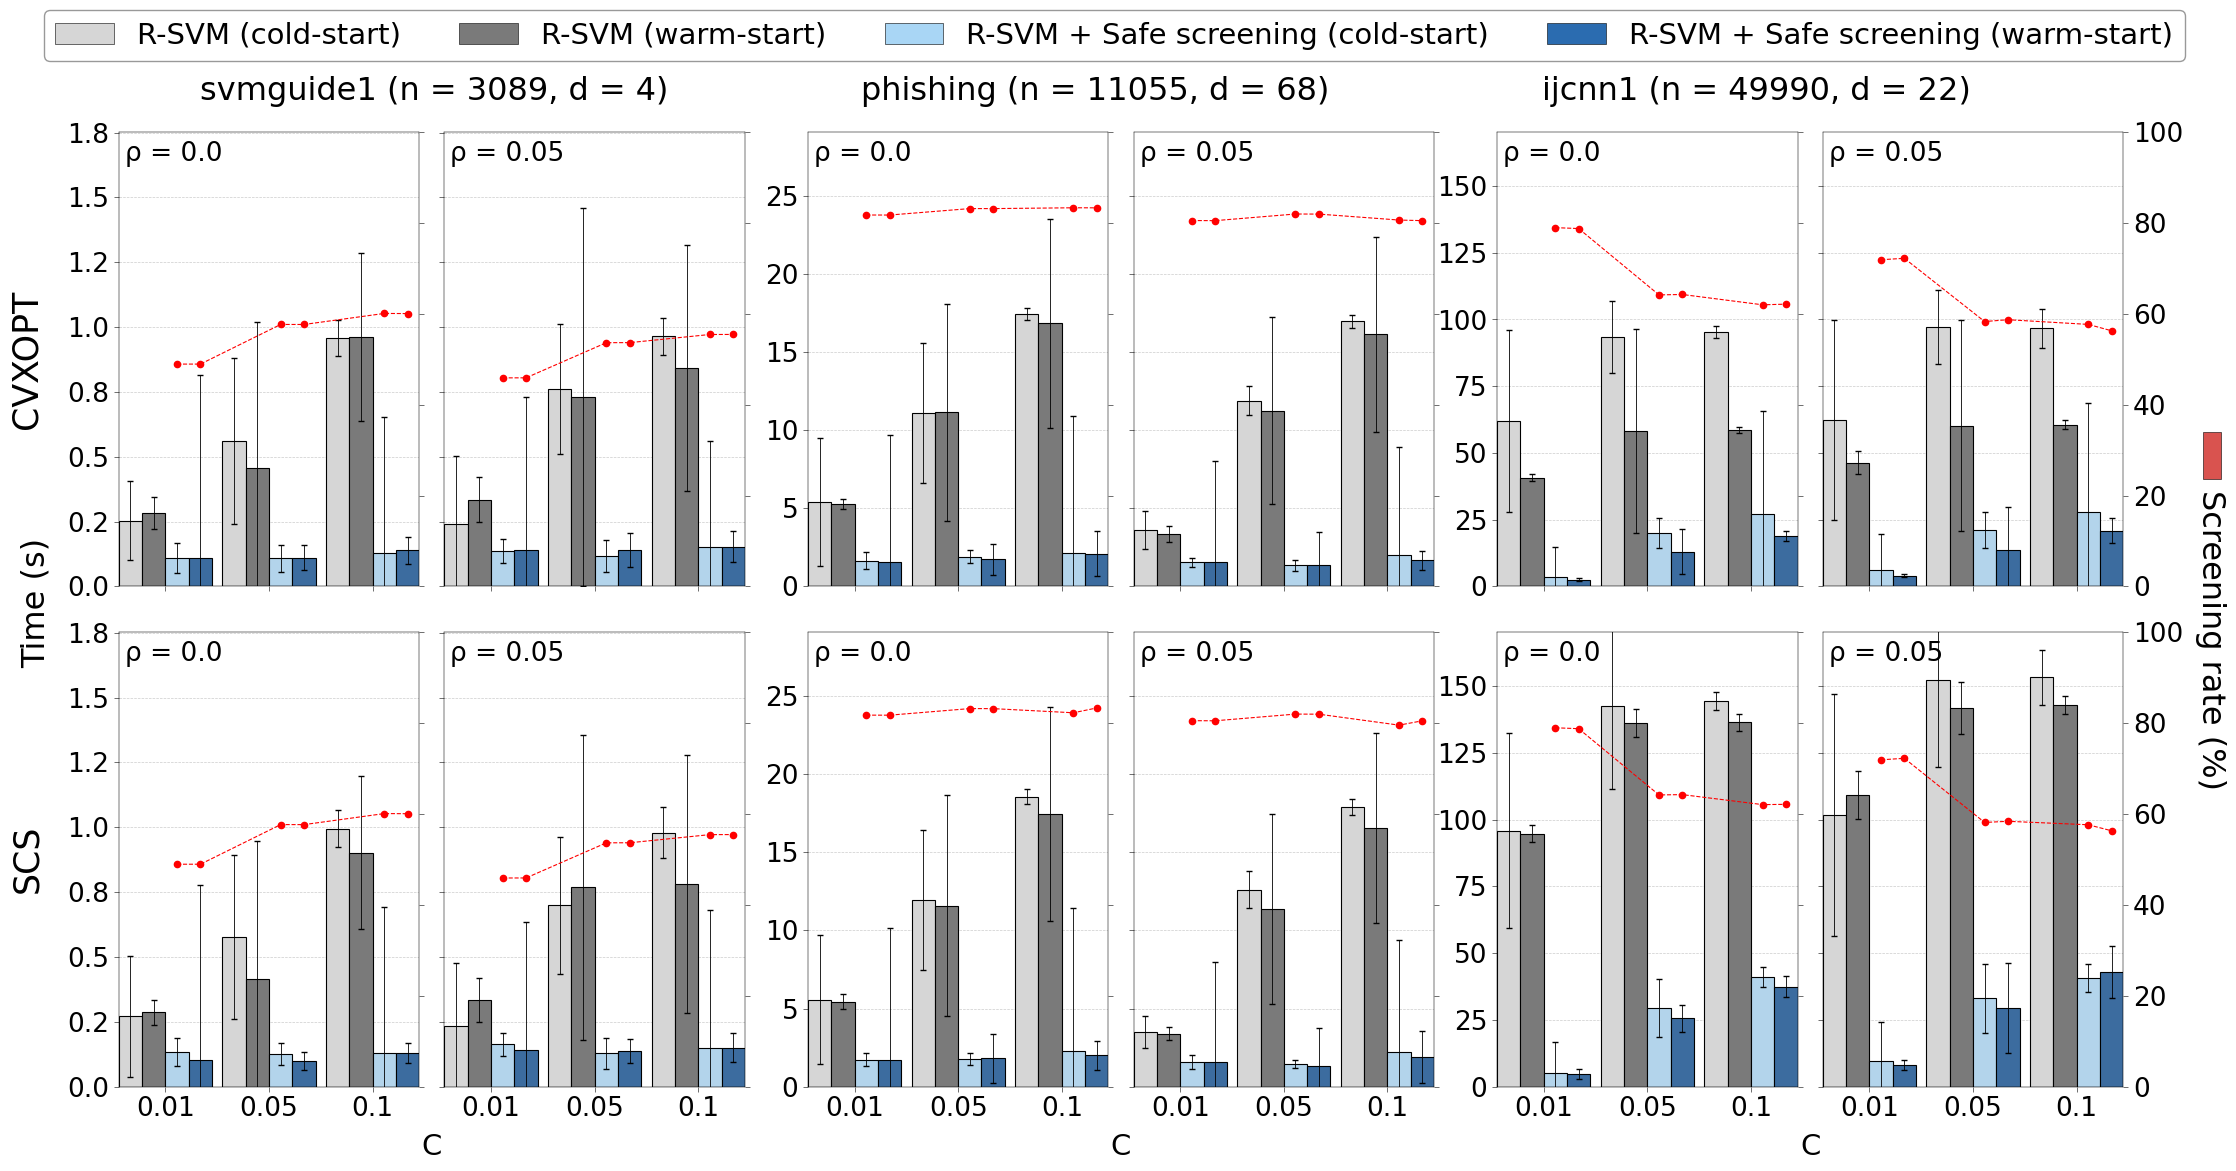

In [ ]:
def plot_performance_analysis(fastness_df_original):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np
    import re

    # 1. Hàm đọc chuỗi "mean ± std"
    def parse_mean_std_string(s):
        if pd.isna(s):
            return np.nan, np.nan

        s_str = str(s)

        match = re.match(
            r"([+\-]?(?:\d*\.)?\d+(?:[eE][+\-]?\d+)?)\s[±]\s"
            r"([+\-]?(?:\d*\.)?\d+(?:[eE][+\-]?\d+)?|nan)",
            s_str
        )

        if match:
            mean = float(match.group(1))
            std_str = match.group(2)
            std = float(std_str) if std_str != 'nan' else np.nan
            return mean, std

        try:
            return float(s_str), np.nan
        except ValueError:
            return np.nan, np.nan

    # 2. Thiết lập kiểu biểu đồ
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.size": 17,
        "axes.titlesize": 21,
        "axes.labelsize": 21,
        "xtick.labelsize": 19,
        "ytick.labelsize": 19,
        "legend.fontsize": 23,
        "legend.title_fontsize": 23,
        "figure.titlesize": 23,
        "text.color": "black",
        "axes.labelcolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.edgecolor": "black",
        "axes.linewidth": 0.2,
        "xtick.major.width": 0.4,
        "ytick.major.width": 0.4,
    })

    # 3. Chuyển bảng kết quả sang dạng long
    plot_data = []

    for _, row in fastness_df_original.iterrows():

        # Dữ liệu của Baseline (R-SVM)
        base_mean, base_std = parse_mean_std_string(
            row['Baseline_Time_Mean_Std']
        )

        plot_data.append({
            'Dataset': row['Dataset'],
            'Solver': row['Solver'],
            'WarmStart': row['WarmStart'],
            'C': row['C'],
            'Rho': row['Rho'],
            'Method': 'R-SVM',
            'Time_Mean': base_mean,
            'Time_Std': base_std,
            'ScreeningRate_Mean': np.nan,
            'ScreeningRate_Std': np.nan
        })

        # Dữ liệu của Screening (R-SVM + Safe screening)
        scr_mean, scr_std = parse_mean_std_string(
            row['TotalScreeningTime_Mean_Std']
        )

        rate_mean, rate_std = parse_mean_std_string(
            row['ScreeningRate']
        )

        plot_data.append({
            'Dataset': row['Dataset'],
            'Solver': row['Solver'],
            'WarmStart': row['WarmStart'],
            'C': row['C'],
            'Rho': row['Rho'],
            'Method': 'R-SVM + Safe screening',
            'Time_Mean': scr_mean,
            'Time_Std': scr_std,
            'ScreeningRate_Mean': rate_mean,
            'ScreeningRate_Std': rate_std
        })

    df_long = pd.DataFrame(plot_data)

    # 4. Chọn các giá trị rho cần vẽ
    RHO_VALS_TO_PLOT = [0.0, 0.05]

    df_filtered_rhos = df_long[
        df_long["Rho"].isin(RHO_VALS_TO_PLOT)
    ].copy()

    # 5. Thông tin các bộ dữ liệu
    dataset_info = {
        'svmguide1': {'n': 3089, 'd': 4},
        'phishing': {'n': 11055, 'd': 68},
        'ijcnn1': {'n': 49990, 'd': 22}
    }

    # 6. Thứ tự dataset và solver
    dataset_list = [
        'svmguide1',
        'phishing',
        'ijcnn1'
    ]

    solver_list = sorted(
        df_filtered_rhos["Solver"].unique()
    )

    # 7. Tạo nhãn kết hợp Method và Warm Start với tên mới (đã đổi thành cold-start / warm-start)
    ws_label = df_filtered_rhos["WarmStart"].map({True: "warm-start", False: "cold-start"})
    df_filtered_rhos["Method_WarmStart"] = (
        df_filtered_rhos["Method"]
        + " ("
        + ws_label
        + ")"
    )

    # 8. Thiết lập kích thước figure và subplot
    n_rows = len(solver_list)
    n_cols = len(dataset_list) * len(RHO_VALS_TO_PLOT)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.2 * n_cols, 6.2 * n_rows),
        squeeze=False,
        gridspec_kw={
            'wspace': 0.1,
            'hspace': 0.1
        }
    )

    PAIR_WSPACE = 0.01
    DATASET_WSPACE = 0.025

    # 9. Thứ tự và màu của các nhóm cột theo nhãn mới
    bar_hue_order = [
        "R-SVM (cold-start)",
        "R-SVM (warm-start)",
        "R-SVM + Safe screening (cold-start)",
        "R-SVM + Safe screening (warm-start)"
    ]

    bar_palette = {
        "R-SVM (cold-start)": "#D6D6D6",
        "R-SVM (warm-start)": "#7A7A7A",
        "R-SVM + Safe screening (cold-start)": "#A9D6F5",
        "R-SVM + Safe screening (warm-start)": "#2B6CB0"
    }

    # 10. Tính giới hạn chung của trục thời gian theo từng Dataset
    ylim_dict = {}

    for dataset_name in dataset_list:
        dataset_df = df_filtered_rhos[
            df_filtered_rhos["Dataset"] == dataset_name
        ].copy()

        dataset_df = dataset_df[
            dataset_df["Time_Mean"].notna() &
            dataset_df["Time_Mean"].apply(np.isfinite)
        ]

        if dataset_df.empty:
            max_y = 1.0
        else:
            max_val_per_group = (
                dataset_df["Time_Mean"]
                + dataset_df["Time_Std"].fillna(0)
            ).max()

            if not np.isfinite(max_val_per_group) or max_val_per_group <= 0:
                max_y = dataset_df["Time_Mean"].max()
            else:
                max_y = max_val_per_group

            if not np.isfinite(max_y) or max_y <= 0:
                max_y = 1.0

            max_y = max_y * 1.05

        for solver_name in solver_list:
            for rho_val_to_plot in RHO_VALS_TO_PLOT:
                ylim_dict[(dataset_name, solver_name, rho_val_to_plot)] = max_y

    # 11. Vẽ toàn bộ các subplot
    for row_idx, solver_name in enumerate(solver_list):
        for col_dataset_idx, dataset_name in enumerate(dataset_list):
            for col_rho_idx, rho_val_to_plot in enumerate(RHO_VALS_TO_PLOT):

                current_col_idx = (
                    col_dataset_idx * len(RHO_VALS_TO_PLOT)
                    + col_rho_idx
                )

                ax1 = axes[row_idx][current_col_idx]

                current_df = df_filtered_rhos[
                    (df_filtered_rhos["Dataset"] == dataset_name) &
                    (df_filtered_rhos["Solver"] == solver_name) &
                    (df_filtered_rhos["Rho"] == rho_val_to_plot)
                ].copy()

                # 11.1. Vẽ biểu đồ cột thời gian
                sns.barplot(
                    data=current_df,
                    x="C",
                    y="Time_Mean",
                    hue="Method_WarmStart",
                    hue_order=bar_hue_order,
                    palette=bar_palette,
                    errorbar=None,
                    edgecolor="black",
                    linewidth=0.8,
                    width=0.90,
                    legend=False,
                    ax=ax1
                )

                # 11.1b. Vẽ thủ công thanh error bar (std)
                x_coords = []
                y_coords = []
                std_vals = []

                for p in ax1.patches:
                    height = p.get_height()
                    if np.isnan(height) or height == 0:
                        continue
                    x_center = p.get_x() + p.get_width() / 2.0
                    x_coords.append(x_center)
                    y_coords.append(height)

                for c_val in sorted(current_df["C"].unique()):
                    for hue_name in bar_hue_order:
                        sub = current_df[
                            (current_df["C"] == c_val) &
                            (current_df["Method_WarmStart"] == hue_name)
                        ]
                        if not sub.empty:
                            val = sub["Time_Std"].values[0]
                            std_vals.append(0 if pd.isna(val) else val)

                if len(x_coords) > 0 and len(x_coords) == len(std_vals):
                    ax1.errorbar(
                        x_coords,
                        y_coords,
                        yerr=std_vals,
                        fmt='none',
                        c='black',
                        capsize=2,
                        elinewidth=0.6,
                        zorder=15
                    )

                # 11.2. Thiết lập trục Y bên trái cho thời gian
                y_max = ylim_dict[
                    (dataset_name, solver_name, rho_val_to_plot)
                ]

                ax1.set_ylim(0, y_max)

                ax1.grid(
                    True,
                    axis='y',
                    linestyle='--',
                    linewidth=0.5,
                    color='gray',
                    alpha=0.4,
                    zorder=0
                )
                ax1.set_axisbelow(True)

                # 11.3. Thiết lập vị trí và độ rộng của các cột
                n_c = current_df["C"].nunique()
                n_hue = len(bar_hue_order)

                group_width = 0.90
                bar_width = group_width / n_hue

                left_edge = -group_width / 2
                right_edge = (n_c - 1) + group_width / 2

                ax1.set_xlim(left_edge, right_edge)
                ax1.margins(x=0)

                # 11.4. Tạo trục Y phụ bên phải cho Screening Rate
                ax2 = ax1.twinx()

                screening_df = current_df[
                    current_df["Method"] == "R-SVM + Safe screening"
                ].copy()

                screening_df = screening_df.sort_values(
                    ["C", "WarmStart"]
                )

                x_positions = []
                rate_values = []
                c_values = sorted(current_df["C"].unique())

                for c_idx, c_value in enumerate(c_values):
                    c_screen = screening_df[screening_df["C"] == c_value]
                    for warm_start in [False, True]:
                        row_rate = c_screen[c_screen["WarmStart"] == warm_start]
                        if row_rate.empty:
                            continue

                        hue_idx = 2 if warm_start is False else 3
                        x = (
                            c_idx
                            - group_width / 2
                            + bar_width * hue_idx
                            + bar_width / 2
                        )
                        rate = row_rate["ScreeningRate_Mean"].iloc[0]
                        if pd.notna(rate):
                            x_positions.append(x)
                            rate_values.append(rate)

                if len(x_positions) > 0:
                    ax2.plot(
                        x_positions,
                        rate_values,
                        color="red",
                        linestyle="--",
                        linewidth=0.8,
                        marker="o",
                        markersize=4.5,
                        markerfacecolor="red",
                        markeredgecolor="red",
                        zorder=5
                    )

                ax2.set_ylim(0, 1.0)
                ax2.set_yticks(np.arange(0, 1.01, 0.2))
                ax2.set_yticklabels([f"{int(x * 100)}" for x in np.arange(0, 1.01, 0.2)])
                ax2.spines["right"].set_color("red")

                is_last_column = (current_col_idx == n_cols - 1)
                is_last_in_pair = (col_rho_idx == len(RHO_VALS_TO_PLOT) - 1)
                show_right_ytick = (current_col_idx >= 5)

                if is_last_column:
                    ax2.tick_params(axis="y", labelsize=19, colors="black", labelright=True)
                elif is_last_in_pair:
                    ax2.set_ylabel("")
                    ax2.tick_params(axis="y", labelsize=19, colors="black", labelright=show_right_ytick, labelleft=False)
                else:
                    ax2.set_ylabel("")
                    ax2.tick_params(axis="y", labelright=show_right_ytick, labelleft=False, colors="black")

                ax2.spines["right"].set_color("black")

                if row_idx == n_rows - 1:
                    ax1.set_xlabel("", fontsize=21, color="black", fontweight="normal")
                else:
                    ax1.set_xlabel("")

                if current_col_idx == 0:
                    ax1.set_ylabel("", fontsize=21, color="black", fontweight="normal")
                else:
                    ax1.set_ylabel("")

                from matplotlib.ticker import FormatStrFormatter

                if col_rho_idx == 0:
                    ax1.tick_params(axis="y", labelsize=19, colors="black")
                    if dataset_name == "svmguide1":
                        ax1.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
                else:
                    ax1.tick_params(axis="y", labelleft=False, colors="black")

                if row_idx == 0:
                    ax1.tick_params(axis="x", labelbottom=False, colors="black")
                else:
                    ax1.tick_params(axis="x", labelsize=19, colors="black")

                ax1.text(
                    0.02, 0.98,
                    f'ρ = {rho_val_to_plot}',
                    transform=ax1.transAxes,
                    fontsize=19,
                    color='black',
                    ha='left',
                    va='top'
                )

    # 12. Ghi tên solver
    for row_idx, solver_name in enumerate(solver_list):
        axes[row_idx][n_cols - 1].annotate(
            solver_name,
            xy=(-5.92, 0.5),
            xycoords="axes fraction",
            ha="right",
            va="center",
            fontsize=25,
            fontweight="normal",
            color="black",
            rotation=90
        )

    # 13. Ghi tên dataset
    for col_dataset_idx, dataset_name in enumerate(dataset_list):
        first_subplot_in_group = axes[0][col_dataset_idx * len(RHO_VALS_TO_PLOT)]
        last_subplot_in_group = axes[0][col_dataset_idx * len(RHO_VALS_TO_PLOT) + len(RHO_VALS_TO_PLOT) - 1]

        bbox0 = first_subplot_in_group.get_position()
        bbox1 = last_subplot_in_group.get_position()
        center_x_fig = (bbox0.x0 + bbox1.x1) / 2

        info = dataset_info.get(dataset_name, {'n': '?', 'd': '?'})
        formatted_dataset_name = f"{dataset_name} (n = {info['n']}, d = {info['d']})"

        fig.text(
            center_x_fig, 0.90,
            formatted_dataset_name,
            ha='center', va='bottom',
            fontsize=23, fontweight='normal', color='black',
            transform=fig.transFigure
        )

    # 14. Tạo legend cho các cột thời gian với tên mới
    bar_handles = [
        plt.Rectangle((0, 0), 1, 1, fc=bar_palette[k], ec="black", linewidth=0.4)
        for k in bar_hue_order
    ]

    fig.legend(
        bar_handles,
        bar_hue_order,
        loc="upper center",
        bbox_to_anchor=(0.52, 0.99),
        ncol=len(bar_hue_order),
        fontsize=21,
        frameon=True,
        edgecolor="gray"
    )

    # 15. Điều chỉnh khoảng cách giữa các subplot
    fig.canvas.draw()

    for row_idx in range(n_rows):
        positions = [
            axes[row_idx][col_idx].get_position()
            for col_idx in range(n_cols)
        ]
        ax_width = positions[0].width
        current_x = positions[0].x0

        for dataset_idx in range(len(dataset_list)):
            rho0_idx = dataset_idx * 2
            ax_rho0 = axes[row_idx][rho0_idx]
            ax_rho0.set_position([current_x, positions[rho0_idx].y0, ax_width, positions[rho0_idx].height])

            rho1_idx = dataset_idx * 2 + 1
            x_rho1 = current_x + ax_width + PAIR_WSPACE
            ax_rho1 = axes[row_idx][rho1_idx]
            ax_rho1.set_position([x_rho1, positions[rho1_idx].y0, ax_width, positions[rho1_idx].height])

            current_x = x_rho1 + ax_width + DATASET_WSPACE

    for col_dataset_idx, dataset_name in enumerate(dataset_list):
        first_sub = axes[n_rows - 1][col_dataset_idx * len(RHO_VALS_TO_PLOT)]
        last_sub = axes[n_rows - 1][col_dataset_idx * len(RHO_VALS_TO_PLOT) + len(RHO_VALS_TO_PLOT) - 1]

        bbox0 = first_sub.get_position()
        bbox1 = last_sub.get_position()
        center_x_fig = (bbox0.x0 + bbox1.x1) / 2
        fig.text(
            center_x_fig, 0.05,
            "C",
            ha='center', va='bottom',
            fontsize=21, color='black',
            transform=fig.transFigure
        )

    fig.text(
        0.092, 0.5,
        "Time (s)",
        ha="center", va="center",
        fontsize=23, color="black",
        rotation=90, transform=fig.transFigure
    )

    from matplotlib.patches import Rectangle
    fig.add_artist(Rectangle(
        (0.952, 0.6), 0.007, 0.038,
        transform=fig.transFigure,
        facecolor="#D9534F",
        edgecolor="black",
        linewidth=0.4,
        clip_on=False
    ))

    fig.text(
        0.949, 0.47,
        "Screening rate (%)",
        ha="left", va="center",
        fontsize=23, color="black",
        rotation=-90, transform=fig.transFigure
    )

    plt.tight_layout(rect=[0.0, 0.02, 1.0, 0.90])
    plt.savefig(
        '/content/drive/MyDrive/Paper_SSRSVM_repo/figures/performance_analysis.pdf',
        bbox_inches='tight'
    )
    plt.show()

# --- Phần đọc file và gọi hàm giữ nguyên ---
FASTNESS_FILE = '/content/drive/MyDrive/RSVM_Experiments_final/fastness_results.csv'

if not os.path.exists(FASTNESS_FILE):
    raise FileNotFoundError(
        f'Không tìm thấy file:\n{FASTNESS_FILE}'
    )

fastness_df = pd.read_csv(FASTNESS_FILE)

print(f'Loaded fastness results from:\n{FASTNESS_FILE}')
print(f'Number of rows: {len(fastness_df)}')

plot_performance_analysis(fastness_df)

## Delta Objective and Relative Objective Difference

**TOST-test Accuracy, AUC, F1**

In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.stats import ttest_1samp


def paired_tost(x_base, x_screen, margin):
    """
    Paired TOST for:
        H0: mean(diff) <= -margin
        H1: mean(diff) > -margin

        H0: mean(diff) >= margin
        H1: mean(diff) < margin

    diff = Screening - Baseline

    Returns the maximum of the two one-sided p-values.
    """

    paired = pd.concat(
        [
            pd.Series(x_base).reset_index(drop=True),
            pd.Series(x_screen).reset_index(drop=True)
        ],
        axis=1
    ).dropna()

    if len(paired) < 2:
        return np.nan

    base = paired.iloc[:, 0].to_numpy(dtype=float)
    screen = paired.iloc[:, 1].to_numpy(dtype=float)

    diff = screen - base

    if np.std(diff, ddof=1) == 0:
        mean_diff = np.mean(diff)

        if -margin < mean_diff < margin:
            return 0.0
        else:
            return 1.0

    p_lower = ttest_1samp(
        diff,
        popmean=-margin,
        alternative='greater'
    ).pvalue

    p_upper = ttest_1samp(
        diff,
        popmean=margin,
        alternative='less'
    ).pvalue

    return max(p_lower, p_upper)


def create_objective_accuracy_table(
    benchmark_file='/content/drive/MyDrive/Paper_SSRSVM_repo/results/master_results.csv',
    output_file='/content/drive/MyDrive/Paper_SSRSVM_repo/results/objective_accuracy_results.csv',
    tost_margins=None
):

    grouping_cols = ['Dataset', 'Solver', 'WarmStart', 'C', 'Rho']
    required_metrics = ['Objective', 'Accuracy', 'AUC', 'F1']

    if tost_margins is None:
        tost_margins = {
            'Objective': 0.01,
            'Accuracy': 0.01,
            'AUC': 0.01,
            'F1': 0.01
        }

    if not os.path.exists(benchmark_file):
        raise FileNotFoundError(
            f'Không tìm thấy file:\n{benchmark_file}'
        )

    df = pd.read_csv(benchmark_file)

    required = (
        grouping_cols
        + ['Method', 'Seed']
        + required_metrics
    )

    missing = [c for c in required if c not in df.columns]

    if missing:
        raise ValueError(f'Thiếu các cột: {missing}')

    if 'Status' in df.columns:
        df = df[
            df['Status'].astype(str).str.upper().eq('SUCCESS')
        ].copy()

    for col in required_metrics + ['C', 'Rho', 'Seed']:
        df[col] = pd.to_numeric(
            df[col],
            errors='coerce'
        )

    df['WarmStart'] = (
        df['WarmStart']
        .astype(str)
        .str.upper()
        .map({
            'TRUE': True,
            'FALSE': False
        })
    )

    df['Method'] = (
        df['Method']
        .astype(str)
        .str.lower()
        .replace({
            'baseline': 'Baseline',
            'screening': 'Screening'
        })
    )

    df.dropna(
        subset=grouping_cols
        + ['Method', 'Seed']
        + required_metrics,
        inplace=True
    )

    # 1. CALCULATE TOST FROM PAIRED SEEDS
    tost_group_cols = grouping_cols + ['Seed']

    base_df = (
        df[df['Method'] == 'Baseline']
        [tost_group_cols + required_metrics]
        .copy()
    )

    screen_df = (
        df[df['Method'] == 'Screening']
        [tost_group_cols + required_metrics]
        .copy()
    )

    paired_df = pd.merge(
        base_df,
        screen_df,
        on=tost_group_cols,
        suffixes=('_Base', '_Screen'),
        how='inner'
    )

    tost_rows = []

    for group_values, group in paired_df.groupby(
        grouping_cols,
        dropna=False
    ):

        row = dict(
            zip(grouping_cols, group_values)
        )

        for metric in required_metrics:

            base_values = group[f'{metric}_Base']
            screen_values = group[f'{metric}_Screen']

            p_value = paired_tost(
                base_values,
                screen_values,
                tost_margins[metric]
            )

            row[f'{metric}_pvalue'] = p_value

        tost_rows.append(row)

    tost_df = pd.DataFrame(tost_rows)

    # 2. ORIGINAL MEAN ± STD CALCULATION
    #    THIS PART IS KEPT CONSISTENT WITH THE ORIGINAL CODE
    grouped = (
        df.groupby(
            grouping_cols + ['Method']
        )[required_metrics]
        .agg(['mean', 'std'])
        .reset_index()
    )

    grouped.columns = [
        '_'.join(col).strip('_')
        for col in grouped.columns.values
    ]

    pivot_values = []

    for metric in required_metrics:
        pivot_values.append(f'{metric}_mean')
        pivot_values.append(f'{metric}_std')

    objective_accuracy_df = (
        grouped
        .pivot(
            index=grouping_cols,
            columns='Method',
            values=pivot_values
        )
        .reset_index()
    )

    objective_accuracy_df.columns = [
        '_'.join(col).strip('_')
        if isinstance(col, tuple)
        else col
        for col in objective_accuracy_df.columns
    ]

    rename_map = {}

    for metric in required_metrics:

        rename_map[
            f'{metric}_mean_Baseline'
        ] = f'{metric}_Base_Mean'

        rename_map[
            f'{metric}_std_Baseline'
        ] = f'{metric}_Base_Std'

        rename_map[
            f'{metric}_mean_Screening'
        ] = f'{metric}_Screen_Mean'

        rename_map[
            f'{metric}_std_Screening'
        ] = f'{metric}_Screen_Std'

    objective_accuracy_df.rename(
        columns=rename_map,
        inplace=True
    )

    # 3. CREATE FINAL OUTPUT
    #    Base -> Screen -> TOST p-value
    final_output_cols = grouping_cols.copy()

    for metric in required_metrics:

        base_mean = f'{metric}_Base_Mean'
        base_std = f'{metric}_Base_Std'

        screen_mean = f'{metric}_Screen_Mean'
        screen_std = f'{metric}_Screen_Std'

        base_col = f'{metric}_Base'
        screen_col = f'{metric}_Screen'

        p_col = f'{metric}_p-value'

        objective_accuracy_df[base_col] = (
            objective_accuracy_df.apply(
                lambda row: (
                    f"{row[base_mean]:.4f} ± {row[base_std]:.4f}"
                    if pd.notna(row[base_mean])
                    and pd.notna(row[base_std])
                    else (
                        f"{row[base_mean]:.4f}"
                        if pd.notna(row[base_mean])
                        else 'NaN'
                    )
                ),
                axis=1
            )
        )

        objective_accuracy_df[screen_col] = (
            objective_accuracy_df.apply(
                lambda row: (
                    f"{row[screen_mean]:.4f} ± {row[screen_std]:.4f}"
                    if pd.notna(row[screen_mean])
                    and pd.notna(row[screen_std])
                    else (
                        f"{row[screen_mean]:.4f}"
                        if pd.notna(row[screen_mean])
                        else 'NaN'
                    )
                ),
                axis=1
            )
        )

        # Merge TOST p-value
        if not tost_df.empty:

            objective_accuracy_df = objective_accuracy_df.merge(
                tost_df[
                    grouping_cols + [f'{metric}_pvalue']
                ],
                on=grouping_cols,
                how='left'
            )

        objective_accuracy_df.rename(
            columns={
                f'{metric}_pvalue': p_col
            },
            inplace=True
        )

        final_output_cols.extend([
            base_col,
            screen_col,
            p_col
        ])

    objective_accuracy_df = objective_accuracy_df[
        final_output_cols
    ]

    # 4. SAVE
    objective_accuracy_df.to_csv(
        output_file,
        index=False,
        encoding='utf-8'
    )

    print(f'Result saved to: {output_file}')
    print(f'Number of groups: {len(objective_accuracy_df)}')

    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)

    display(objective_accuracy_df)

    # 5. QUICK TOST SUMMARY
    summary_rows = []

    for metric in required_metrics:
        p_col = f'{metric}_p-value'

        pvals = pd.to_numeric(
            objective_accuracy_df[p_col],
            errors='coerce'
        ).dropna()

        n_total = len(pvals)
        n_equiv = (pvals < 0.05).sum()
        n_not_equiv = (pvals >= 0.05).sum()
        equiv_rate = 100 * n_equiv / n_total if n_total > 0 else np.nan

        summary_rows.append({
            'Metric': metric,
            'Total groups': n_total,
            'Equivalent (p < 0.05)': n_equiv,
            'Not equivalent (p >= 0.05)': n_not_equiv,
            'Equivalent rate (%)': equiv_rate
        })

    tost_summary_df = pd.DataFrame(summary_rows)

    print('\n' + '=' * 70)
    print('QUICK TOST SUMMARY')
    print('=' * 70)

    display(
        tost_summary_df.style.format({
            'Equivalent rate (%)': '{:.2f}'
        })
    )

    summary_output = output_file.replace(
        '.csv',
        '_summary.csv'
    )

    tost_summary_df.to_csv(
        summary_output,
        index=False,
        encoding='utf-8'
    )

    print(f'Summary saved to: {summary_output}')

    return objective_accuracy_df


objective_accuracy_df = create_objective_accuracy_table(
    benchmark_file='/content/drive/MyDrive/RSVM_Experiments_final/master_results.csv',
    output_file='/content/drive/MyDrive/RSVM_Experiments_final/objective_accuracy_results.csv',
    tost_margins={
        'Objective': 0.01,
        'Accuracy': 0.005,
        'AUC': 0.005,
        'F1': 0.005
    }
)

Result saved to: /content/drive/MyDrive/RSVM_Experiments_final/objective_accuracy_results.csv
Number of groups: 72


,Dataset,Solver,WarmStart,C,Rho,Objective_Base,Objective_Screen,Objective_p-value,Accuracy_Base,Accuracy_Screen,Accuracy_p-value,AUC_Base,AUC_Screen,AUC_p-value,F1_Base,F1_Screen,F1_p-value
0,ijcnn1,CVXOPT,False,0.01,0.00,56.3192 ± 0.3806,56.3192 ± 0.3806,7.507257e-134,0.9244 ± 0.0042,0.9245 ± 0.0043,6.881783e-35,0.9175 ± 0.0041,0.9175 ± 0.0041,2.462366e-97,0.6283 ± 0.0107,0.6283 ± 0.0106,5.192082e-45
1,ijcnn1,CVXOPT,False,0.01,0.05,61.2007 ± 0.3271,61.2007 ± 0.3271,1.106232e-80,0.9246 ± 0.0037,0.9246 ± 0.0037,9.439156e-73,0.9190 ± 0.0040,0.9190 ± 0.0040,4.448811e-90,0.6270 ± 0.0098,0.6270 ± 0.0098,1.382219e-46
2,ijcnn1,CVXOPT,False,0.05,0.00,275.0826 ± 2.0555,275.0826 ± 2.0555,6.787223e-58,0.9244 ± 0.0032,0.9246 ± 0.0033,2.871497e-24,0.9173 ± 0.0042,0.9173 ± 0.0042,3.303156e-74,0.6276 ± 0.0107,0.6280 ± 0.0108,5.130939e-18
3,ijcnn1,CVXOPT,False,0.05,0.05,301.0001 ± 1.8530,301.0001 ± 1.8530,4.766075e-58,0.9246 ± 0.0035,0.9246 ± 0.0035,5.680290e-56,0.9180 ± 0.0040,0.9180 ± 0.0040,1.326557e-71,0.6289 ± 0.0111,0.6289 ± 0.0110,9.626998e-39
4,ijcnn1,CVXOPT,False,0.10,0.00,548.3638 ± 4.1590,548.3636 ± 4.1590,1.373150e-62,0.9246 ± 0.0036,0.9246 ± 0.0034,2.624776e-22,0.9173 ± 0.0042,0.9173 ± 0.0042,3.922742e-75,0.6281 ± 0.0109,0.6282 ± 0.0107,1.222128e-23
5,ijcnn1,CVXOPT,False,0.10,0.05,600.5712 ± 3.7612,600.5712 ± 3.7612,2.698560e-47,0.9243 ± 0.0037,0.9246 ± 0.0032,1.164858e-16,0.9179 ± 0.0040,0.9179 ± 0.0040,2.202560e-71,0.6287 ± 0.0106,0.6286 ± 0.0107,4.838688e-18
6,ijcnn1,CVXOPT,True,0.01,0.00,56.3192 ± 0.3806,56.3192 ± 0.3806,2.393631e-112,0.9244 ± 0.0042,0.9244 ± 0.0042,2.883180e-66,0.9175 ± 0.0041,0.9175 ± 0.0041,5.028964e-96,0.6283 ± 0.0107,0.6283 ± 0.0107,5.365319e-52
7,ijcnn1,CVXOPT,True,0.01,0.05,61.2007 ± 0.3271,61.2007 ± 0.3271,5.814364e-81,0.9246 ± 0.0037,0.9246 ± 0.0037,1.340360e-68,0.9190 ± 0.0040,0.9190 ± 0.0040,9.512776e-90,0.6270 ± 0.0098,0.6270 ± 0.0098,7.466718e-46
8,ijcnn1,CVXOPT,True,0.05,0.00,275.0826 ± 2.0555,275.0827 ± 2.0555,3.317717e-55,0.9244 ± 0.0032,0.9245 ± 0.0032,3.630310e-54,0.9173 ± 0.0042,0.9173 ± 0.0042,5.828217e-73,0.6276 ± 0.0107,0.6277 ± 0.0106,3.044457e-36
9,ijcnn1,CVXOPT,True,0.05,0.05,301.0001 ± 1.8530,301.0001 ± 1.8530,4.711856e-56,0.9246 ± 0.0035,0.9246 ± 0.0035,2.875570e-55,0.9180 ± 0.0040,0.9180 ± 0.0040,4.199234e-74,0.6290 ± 0.0111,0.6289 ± 0.0111,3.806418e-34



QUICK TOST SUMMARY


,Metric,Total groups,Equivalent (p < 0.05),Not equivalent (p >= 0.05),Equivalent rate (%)
0,Objective,72,72,0,100.00
1,Accuracy,72,72,0,100.00
2,AUC,72,72,0,100.00
3,F1,72,72,0,100.00


Summary saved to: /content/drive/MyDrive/RSVM_Experiments_final/objective_accuracy_results_summary.csv


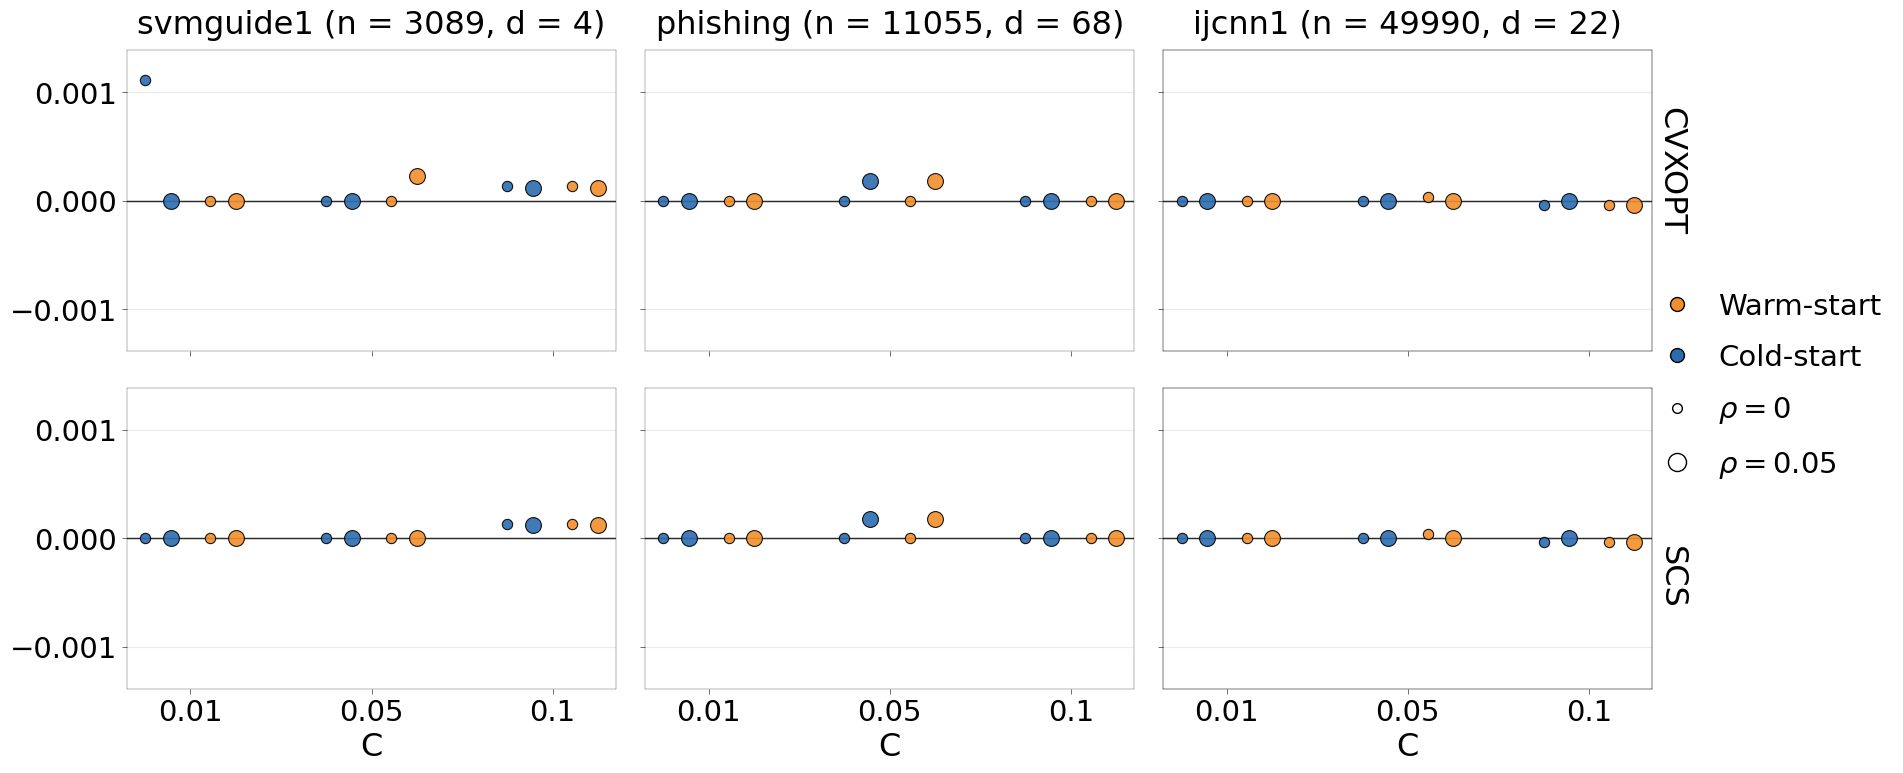

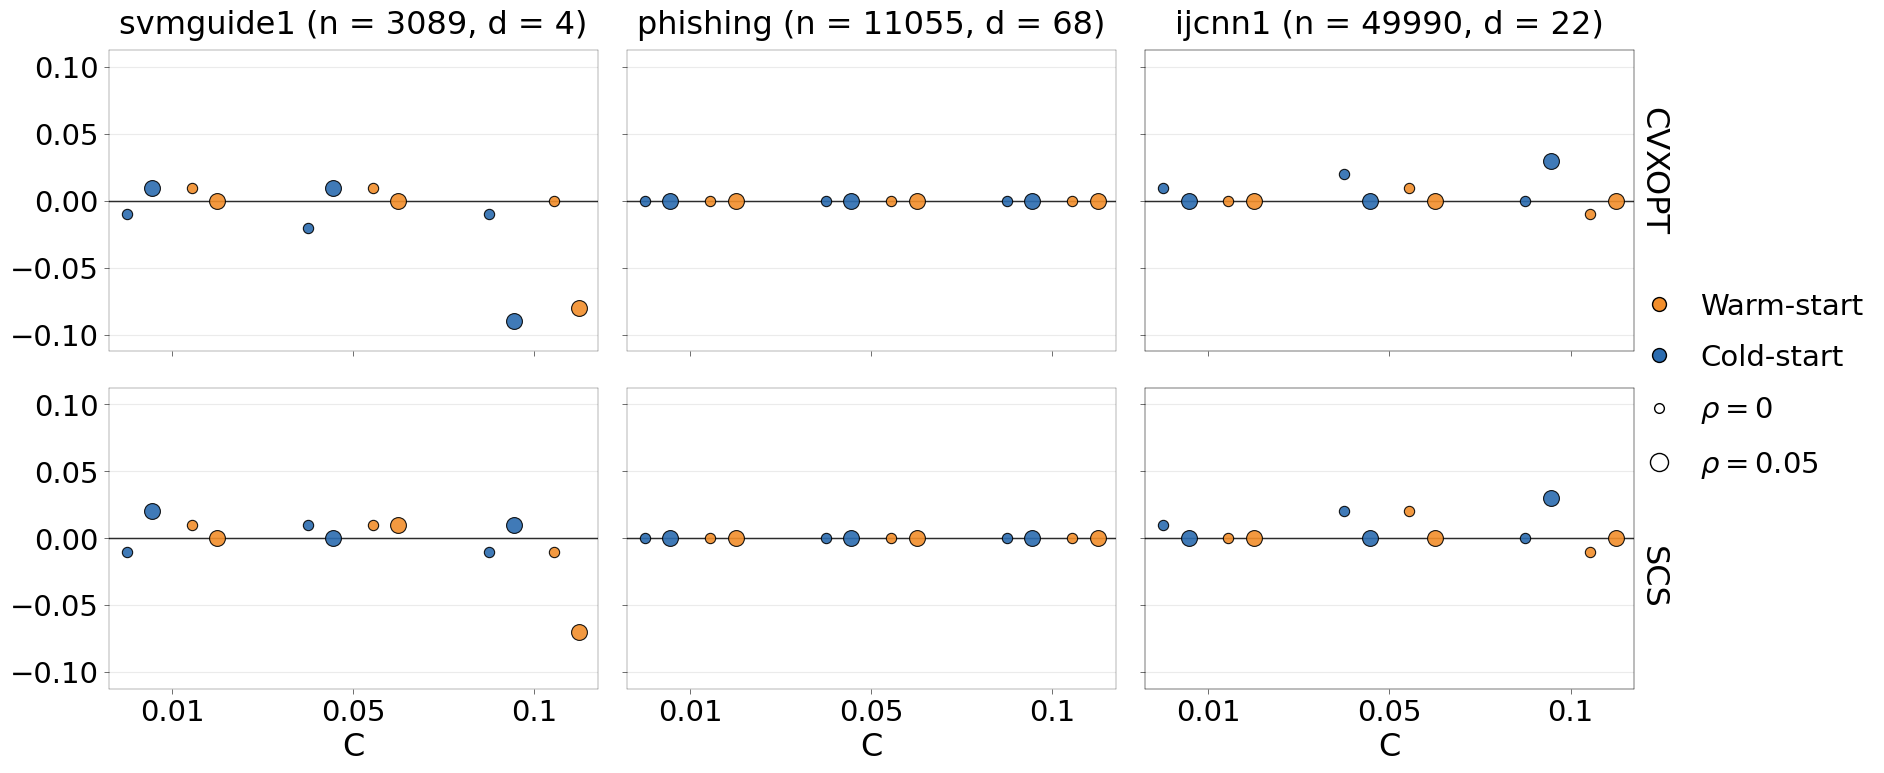

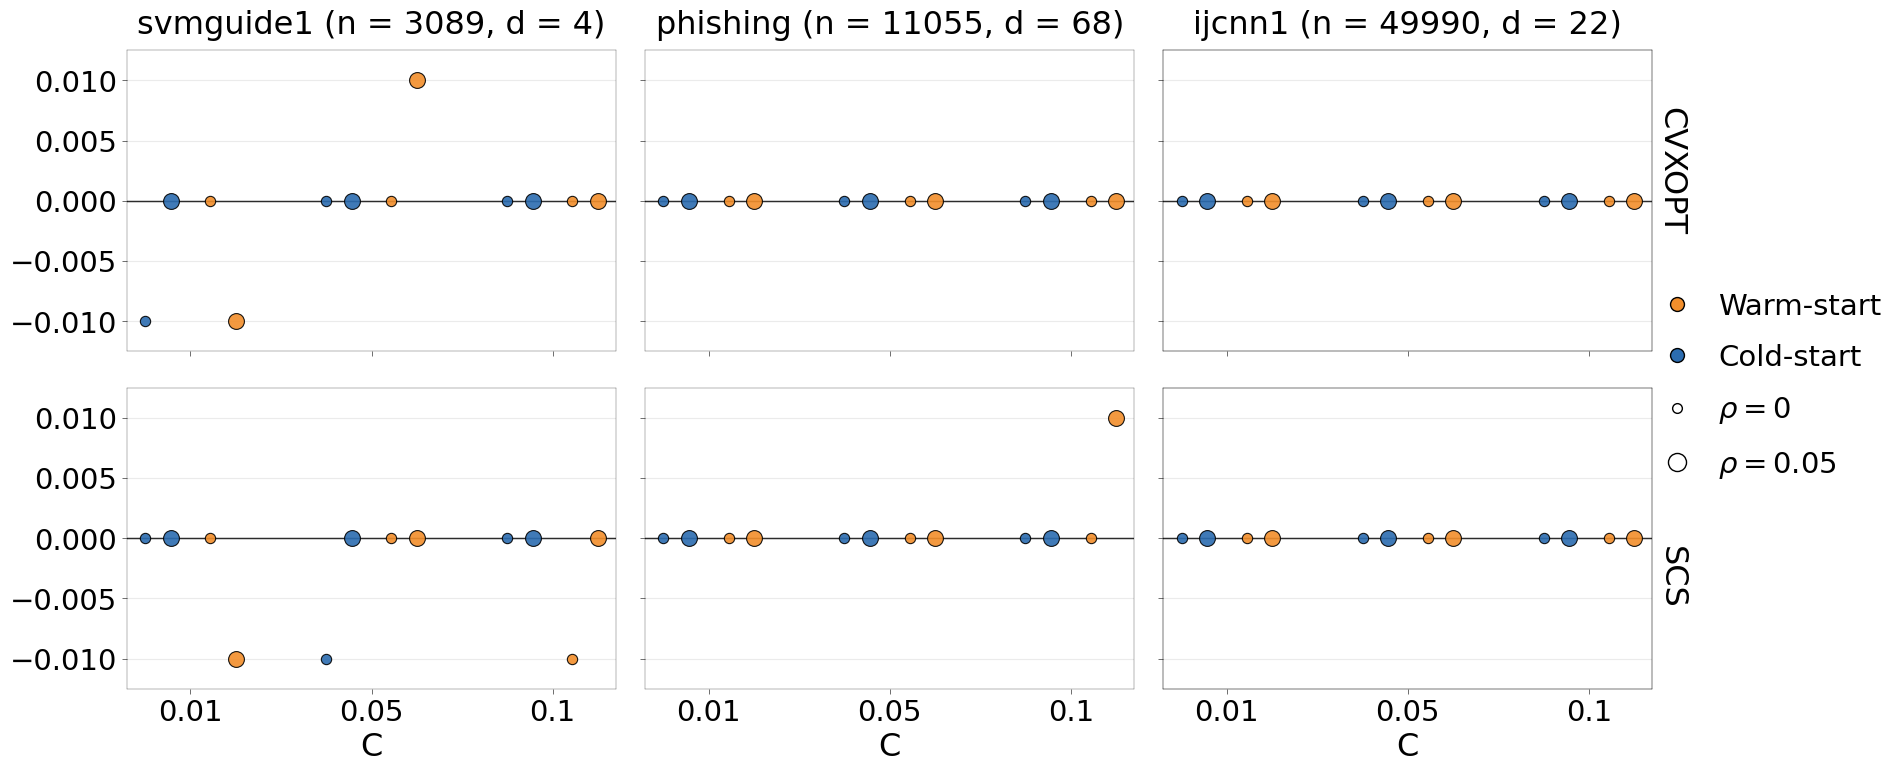

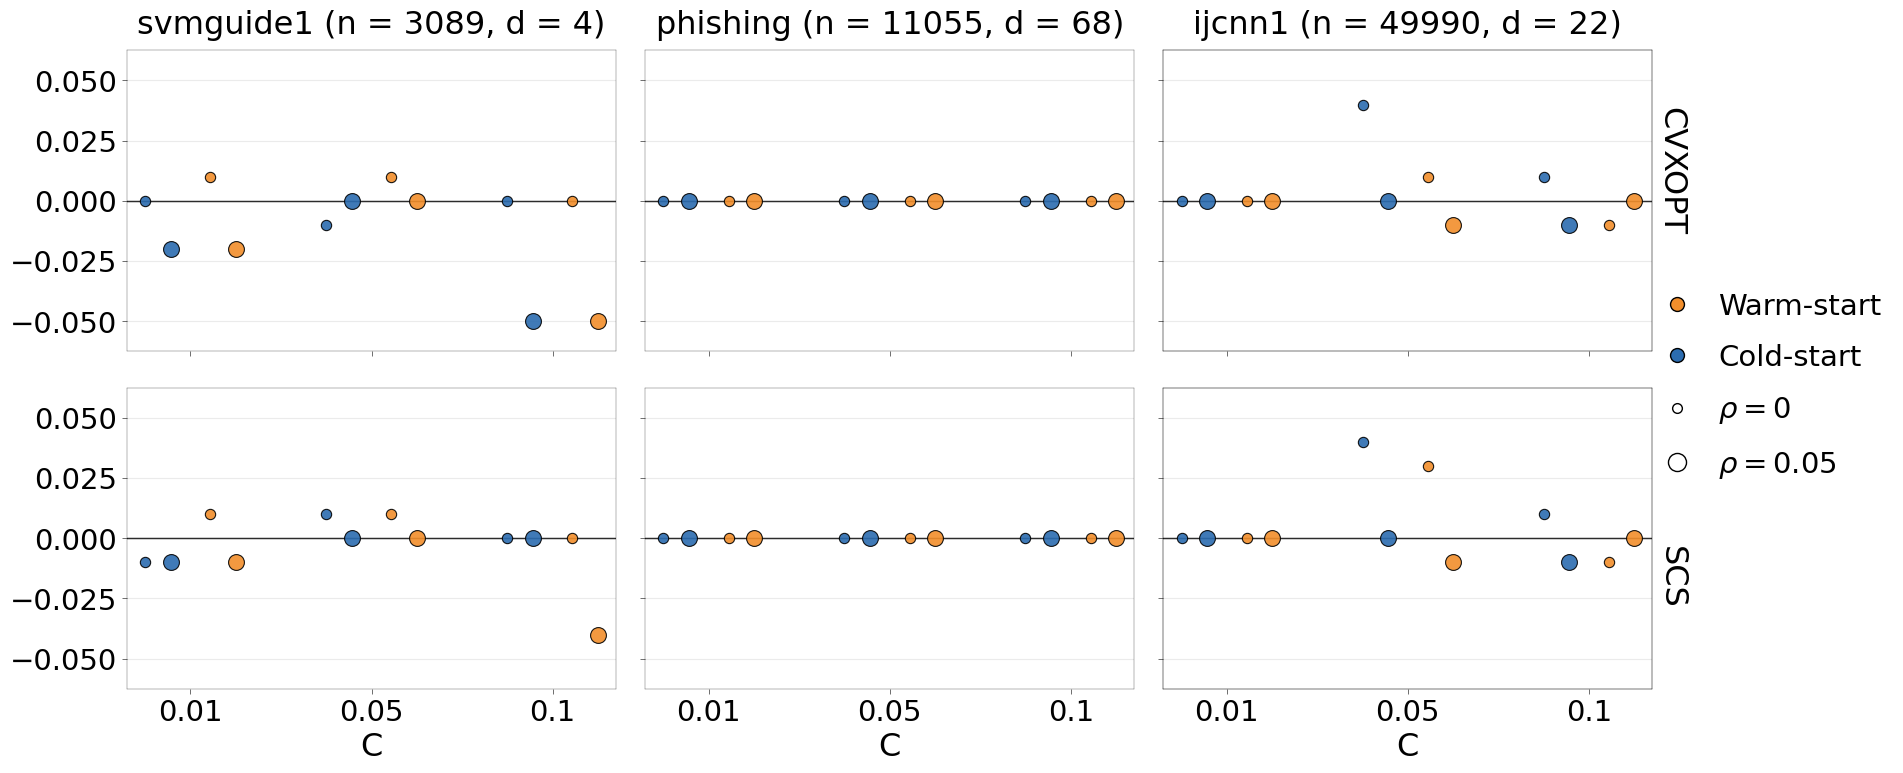

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import re, os

def plot_all_differences(csv_file="/content/drive/MyDrive/Paper_SSRSVM_repo/results/objective_accuracy_results.csv", master_file=None, output_dir='/content/drive/MyDrive/Paper_SSRSVM_repo/figures'):
    os.makedirs(output_dir, exist_ok=True)
    df = pd.read_csv(csv_file)

    def parse_mean_std(s):
        if pd.isna(s): return np.nan, np.nan
        s = str(s).strip()
        m = re.match(r"([+\-]?(?:\d*\.)?\d+(?:[eE][+\-]?\d+)?)\s*±\s*([+\-]?(?:\d*\.)?\d+(?:[eE][+\-]?\d+)?)", s)
        if m: return float(m.group(1)), float(m.group(2))
        try: return float(s), 0.0
        except: return np.nan, np.nan

    metric_columns = ["Objective_Base", "Objective_Screen", "Accuracy_Base", "Accuracy_Screen", "AUC_Base", "AUC_Screen", "F1_Base", "F1_Screen"]
    for col in metric_columns:
        parsed = df[col].apply(parse_mean_std)
        df[col+"_mean"] = parsed.apply(lambda z: z[0])
        df[col+"_std"] = parsed.apply(lambda z: z[1])

    m = df.copy()
    m["Obj_RelDiff_%"] = (m["Objective_Screen_mean"] - m["Objective_Base_mean"]) / np.abs(m["Objective_Base_mean"]) * 100
    m["Acc_AbsDiff_pp"] = (m["Accuracy_Screen_mean"] - m["Accuracy_Base_mean"]) * 100
    m["AUC_AbsDiff_pp"] = (m["AUC_Screen_mean"] - m["AUC_Base_mean"]) * 100
    m["F1_AbsDiff_pp"] = (m["F1_Screen_mean"] - m["F1_Base_mean"]) * 100

    mapping = {"svmguide1": "svmguide1 (n = 3089, d = 4)", "phishing": "phishing (n = 11055, d = 68)", "ijcnn1": "ijcnn1 (n = 49990, d = 22)"}
    m["Dataset_raw"] = m["Dataset"]
    m["Dataset"] = m["Dataset"].map(mapping)
    solver_list = sorted(m["Solver"].unique())
    warmstart_list = sorted(m["WarmStart"].unique())
    c_list = sorted(m["C"].unique())
    rho_list = sorted(m["Rho"].unique())
    dataset_list = list(mapping.values())

    assert len(m) == len(dataset_list) * len(solver_list) * len(warmstart_list) * len(c_list) * len(rho_list)
    assert len(rho_list) == 2 and len(c_list) == 3

    cols = {"Obj": ("Obj_RelDiff_%", "Objective"), "Acc": ("Acc_AbsDiff_pp", "Accuracy"), "AUC": ("AUC_AbsDiff_pp", "AUC"), "F1": ("F1_AbsDiff_pp", "F1 Score")}

    plt.rcParams.update({"font.family": "sans-serif", "font.size": 21, "axes.titlesize": 23, "axes.labelsize": 23, "xtick.labelsize": 21, "ytick.labelsize": 21})
    color_map = {True: "#F28E2B", False: "#2B6CB0"}
    size_map = {rho_list[0]: 55, rho_list[1]: 130}
    x_positions = np.arange(len(c_list))
    n_rows, n_cols = len(solver_list), len(dataset_list)
    figs = {}

    for metric, name in [("Obj", "objective_difference.pdf"), ("Acc", "accuracy_difference.pdf"), ("AUC", "auc_difference.pdf"), ("F1", "f1_difference.pdf")]:
        y_col, title_metric = cols[metric]

        fig, axes = plt.subplots(n_rows, n_cols, squeeze=False, figsize=(5.2 * n_cols + 3, 4.2 * n_rows))
        ymax = m[y_col].abs().max()
        ymax = 1 if ymax == 0 else ymax * 1.25

        for i, solver in enumerate(solver_list):
            for j, dataset in enumerate(dataset_list):
                ax = axes[i, j]
                sub = m[(m["Solver"] == solver) & (m["Dataset"] == dataset)].copy()

                for c_idx, C in enumerate(c_list):
                    for _, row in sub[sub["C"] == C].iterrows():
                        wi = warmstart_list.index(row["WarmStart"])
                        wo = (-.18 if wi == 0 else .18) if len(warmstart_list) == 2 else 0
                        ri = rho_list.index(row["Rho"])
                        ro = (-.07 if ri == 0 else .07) if len(rho_list) == 2 else 0
                        x = c_idx + wo + ro

                        ax.scatter(x, row[y_col], color=color_map[bool(row["WarmStart"])], marker="o", s=size_map[row["Rho"]], edgecolor="black", linewidth=.8, alpha=.9, zorder=3)

                ax.axhline(0, color="black", linewidth=1, zorder=1)
                ax.set_ylim(-ymax, ymax)
                ax.set_xlim(-.35, len(c_list) - .65)
                ax.set_xticks(x_positions)
                ax.set_xticklabels([] if i == 0 else [f"{C:g}" for C in c_list])
                if j > 0: ax.tick_params(axis="y", labelleft=False)
                ax.grid(axis="y", alpha=.25, linewidth=.8)
                if i == 0: ax.set_title(dataset, pad=12)
                if i == n_rows - 1: ax.set_xlabel("C")

                # Giữ lại phần hiển thị tên solver ở cột cuối cùng bên phải
                if j == n_cols - 1:
                    ax_r2 = ax.twinx()
                    ax_r2.set_ylim(ax.get_ylim())
                    ax_r2.set_yticks([])
                    ax_r2.set_ylabel(solver, rotation=270, labelpad=55, fontsize=23)
                    ax_r2.yaxis.set_label_coords(1.07, .6 if i == 0 else .37)

        handles = [
            Line2D([0], [0], marker="o", linestyle="", markerfacecolor="#F28E2B", markeredgecolor="black", markersize=10, label="Warm-start"),
            Line2D([0], [0], marker="o", linestyle="", markerfacecolor="#2B6CB0", markeredgecolor="black", markersize=10, label="Cold-start"),
            Line2D([0], [0], marker="o", linestyle="", markerfacecolor="white", markeredgecolor="black", markersize=7, label=r"$\rho = 0$"),
            Line2D([0], [0], marker="o", linestyle="", markerfacecolor="white", markeredgecolor="black", markersize=13, label=r"$\rho = 0.05$")
        ]

        fig.legend(handles=handles, loc="center left", bbox_to_anchor=(.89, .5), ncol=1, frameon=False, fontsize=21, labelspacing=.8, handletextpad=.4, borderaxespad=.1)
        fig.subplots_adjust(top=.90, bottom=.14, left=.08, right=.90, wspace=.06, hspace=.12)
        figs[metric] = fig
        fig.savefig(os.path.join(output_dir, name), bbox_inches="tight")
        plt.show()

    return figs["Obj"], figs["Acc"], figs["AUC"], figs["F1"]

fig_obj, fig_acc, fig_auc, fig_f1 = plot_all_differences(
    "/content/drive/MyDrive/RSVM_Experiments_final/objective_accuracy_results.csv",
    "/content/drive/MyDrive/RSVM_Experiments_final/master_results.csv",
    "/content/benchmark_plots"
)

In [ ]:
import json
import re

path = "/content/drive/MyDrive/Paper-SSRSVM/Paper_SS-RSVM_final.ipynb"

with open(path, "r", encoding="utf-8") as f:
    nb = json.load(f)

keywords = [
    "breast", "spambase", "svmguide1", "phishing", "ijcnn1",
    "w6a", "a9a", "drive", "mount", "master_results",
    "csv", "pickle", "seed", "solver", "C_VALS", "RHO_VALS"
]

for i, cell in enumerate(nb["cells"]):
    source = "".join(cell.get("source", []))
    found = [k for k in keywords if re.search(re.escape(k), source, re.I)]

    if found:
        print(f"\n===== CELL {i} =====")
        print("Keywords:", found)
        print(source[:2500])


===== CELL 1 =====
Keywords: ['solver']
import os
import shutil
import cvxpy as cp
from google.colab import files

!pip install -q scs cvxpy cvxopt

try:
    solvers = cp.installed_solvers()
    print("Các solver khả dụng:", solvers)
except Exception as e:
    print(f"Lỗi kiểm tra solvers: {e}")

===== CELL 3 =====
Keywords: ['svmguide1', 'phishing', 'ijcnn1']
import numpy as np
from sklearn.datasets import load_svmlight_file
import requests, os, bz2, urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

def download_libsvm_data(url, filename, timeout=30):
    if os.path.exists(filename):
        return load_svmlight_file(filename)
    is_bz2 = url.endswith(".bz2")
    temp_filename = filename + ".bz2" if is_bz2 else filename
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        r = requests.get(url, headers=headers, allow_redirects=True, timeout=timeout, verify=False)
        r.raise_for_status()
        with open(temp_filename, "wb") as f: f.write(r.con